In [28]:
from pathlib import Path

import pandas as pd
from IPython.display import display

PROJECT = Path(
    "/Users/oscarlewis/Desktop/python/trading_portfolio/"
    "uk_portfolio/reversal_signals"
)

snapshot = pd.read_pickle(
    PROJECT
    / "data"
    / "uk_extension_2023_2025_v1"
    / "prepared_2015_2025_v1.pkl"
)

development_end = pd.Timestamp("2022-01-01")

prices = snapshot["prices"].loc[
    snapshot["prices"].index < development_end
].copy()

schedule = snapshot["schedule"].loc[
    snapshot["schedule"].index < development_end
].copy()

del snapshot

display(pd.Series({
    "first_session": schedule.index.min().date(),
    "last_session": schedule.index.max().date(),
    "sessions": len(schedule),
    "tickers": prices["ticker"].nunique(),
    "stock_session_rows": len(prices),
}, name="Development inputs"))

display(prices[["ticker", "adj_close", "Volume"]].head())

first_session         2015-01-02
last_session          2021-12-31
sessions                    1771
tickers                      573
stock_session_rows       1014783
Name: Development inputs, dtype: object

,ticker,adj_close,Volume
Date,,,
2015-01-02,4BB.L,NaN,NaN
2015-01-02,80M.L,0.028750,0.0
2015-01-02,88E.L,0.159907,180539.0
2015-01-02,AAU.L,0.008735,0.0
2015-01-02,AAZ.L,0.066043,54912.0


In [29]:
import sys

source_dir = str(PROJECT / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

import reversal_features

feature_panels = {}

for lookback in (1, 3, 5, 10):
    feature_panels[lookback] = reversal_features.build_raw_reversal_features(prices, schedule, lookback=lookback).set_index("ticker", append=True).sort_index()

# Trace the 10-session calculation for one stock.
example_ticker = "AAZ.L"

stock_close = prices.loc[prices["ticker"].eq(example_ticker), "adj_close"]
stock_features = feature_panels[10].xs(example_ticker, level="ticker")

trace = pd.DataFrame({
    "close_10_sessions_ago": stock_close.shift(10),
    "close_today": stock_close,
    "past_return": stock_features["raw_return"],
    "reversal_score": stock_features["raw_reversal_score"],
})

display(trace.dropna().head().round(6))

,close_10_sessions_ago,close_today,past_return,reversal_score
Date,,,,
2015-01-16,0.066043,0.062305,-0.056604,0.056604
2015-01-19,0.066043,0.061059,-0.075472,0.075472
2015-01-20,0.066043,0.059813,-0.094340,0.094340
2015-01-21,0.066043,0.059813,-0.094340,0.094340
2015-01-22,0.067289,0.059813,-0.111111,0.111111


In [30]:
outcome_panels = {}

for holding in (1, 3, 5):
    outcome_panels[holding] = (
        reversal_features.build_forward_outcomes(
            prices,
            schedule,
            horizon=holding,
        )
        .set_index("ticker", append=True)
        .sort_index()
    )

# Combine past features and future outcomes for one worked example.
example_ticker = "AAZ.L"

past_features = feature_panels[10].xs(
    example_ticker, level="ticker"
)

future_outcomes = outcome_panels[1].xs(
    example_ticker, level="ticker"
)

example = past_features[
    ["signal_time", "raw_return", "raw_reversal_score"]
].join(
    future_outcomes[[
        "entry_time",
        "exit_time",
        "entry_open",
        "exit_open",
        "dividends_earned",
        "forward_return",
        "outcome_observed",
    ]],
    validate="one_to_one",
)

display(
    example.loc[
        example["raw_return"].notna()
        & example["outcome_observed"]
    ].head()
)

,signal_time,raw_return,raw_reversal_score,entry_time,exit_time,entry_open,exit_open,dividends_earned,forward_return,outcome_observed
Date,,,,,,,,,,
2015-01-16,2015-01-16 16:30:00+00:00,-0.056604,0.056604,2015-01-19 08:00:00+00:00,2015-01-20 08:00:00+00:00,0.06000,0.06013,0.0,0.002167,True
2015-01-19,2015-01-19 16:30:00+00:00,-0.075472,0.075472,2015-01-20 08:00:00+00:00,2015-01-21 08:00:00+00:00,0.06013,0.06200,0.0,0.031099,True
2015-01-20,2015-01-20 16:30:00+00:00,-0.094340,0.094340,2015-01-21 08:00:00+00:00,2015-01-22 08:00:00+00:00,0.06200,0.06000,0.0,-0.032258,True
2015-01-21,2015-01-21 16:30:00+00:00,-0.094340,0.094340,2015-01-22 08:00:00+00:00,2015-01-23 08:00:00+00:00,0.06000,0.05855,0.0,-0.024167,True
2015-01-22,2015-01-22 16:30:00+00:00,-0.111111,0.111111,2015-01-23 08:00:00+00:00,2015-01-26 08:00:00+00:00,0.05855,0.06000,0.0,0.024765,True


In [31]:
import json
import numpy as np

spec = json.loads(
    (
        PROJECT
        / "data/uk_holdout_2021_2023_v1/frozen_spec.json"
    ).read_text()
)

grid = (
    pd.DataFrame(spec["configuration_grid"])
    .set_index("configuration_id")
    .sort_index()
)

rules = spec["eligibility"]

activity = prices[["ticker", "Close", "Volume"]].copy()

# These saved prices are already expressed in GBP.
activity["traded_value_proxy_gbp"] = (
    activity["Close"] * activity["Volume"]
)

# Keep missing volume distinct from an observed zero.
activity["reported_zero_volume"] = (
    activity["Volume"].eq(0).astype(float)
    .where(activity["Volume"].notna())
)

liquidity = (
    reversal_features.build_liquidity_features(
        activity,
        schedule,
        lookback=rules["liquidity_lookback_sessions"],
    )
    .set_index("ticker", append=True)
    .sort_index()
)

print(f"Configurations available: {len(grid)}")

Configurations available: 36


In [32]:
keyed_prices = (
    prices.set_index("ticker", append=True).sort_index()
)

valid_close = (
    np.isfinite(keyed_prices["adj_close"])
    & keyed_prices["adj_close"].gt(0)
)

# A 10-session return needs 11 consecutive closing prices.
window = max(feature_panels) + 1

complete_window = valid_close.groupby(
    level="ticker", sort=False
).transform(
    lambda values: (
        values.rolling(window, min_periods=window)
        .sum()
        .eq(window)
    )
)

eligible = (
    liquidity["history_ready"]
    & liquidity["median_traded_value_gbp"].ge(
        rules["min_median_traded_value_gbp"]
    )
    & liquidity["zero_volume_fraction"].le(
        rules["max_zero_volume_fraction"]
    )
)

if rules["require_complete_formation_window"]:
    eligible &= complete_window

if rules["require_positive_signal_day_volume"]:
    eligible &= (
        np.isfinite(keyed_prices["Volume"])
        & keyed_prices["Volume"].gt(0)
    )

for features in feature_panels.values():
    eligible &= np.isfinite(features["raw_reversal_score"])

eligible = eligible.rename("eligible")

# Every formation window receives the same eligibility mask.
for features in feature_panels.values():
    features["eligible"] = eligible

eligible_counts = (
    eligible.groupby(level="Date")
    .sum()
    .rename("eligible_stocks")
)

display(
    eligible_counts.groupby(eligible_counts.index.year)
    .agg(["min", "median", "max"])
)

,min,median,max
Date,,,
2015,0,51.0,56
2016,44,54.0,66
2017,26,75.0,90
2018,48,90.0,100
2019,71,84.0,101
2020,70,110.0,139
2021,138,162.0,198


In [33]:
import reversal_validation

MAX_TARGET_WEIGHT = 0.05

session_positions = np.arange(len(schedule))
decision_dates_by_config = {}
candidate_parts = {}

outcome_columns = [
    "entry_time",
    "exit_time",
    "entry_open",
    "exit_open",
    "dividends_earned",
    "forward_return",
    "outcome_observed",
]

for config in grid.itertuples():
    config_id = int(config.Index)
    formation = int(config.formation_sessions)
    holding = int(config.holding_sessions)

    calendar = reversal_validation.build_rebalance_calendar(
        schedule,
        anchor=pd.Timestamp(spec["rebalance_anchor"]),
        rebalance_sessions=int(config.rebalance_sessions),
    )

    # The scheduled exit must fall within our loaded history.
    complete_horizon = (
        session_positions + 1 + holding < len(schedule)
    )

    decision_dates = schedule.index[
        calendar["is_rebalance"].to_numpy()
        & complete_horizon
    ]

    # Preserve dates even when no stocks are selected.
    decision_dates_by_config[config_id] = decision_dates

    features = feature_panels[formation]

    ranked = reversal_validation.select_reversal_candidates(
        features.loc[
            features.index.get_level_values("Date")
            .isin(decision_dates)
        ],
        score_column="raw_reversal_score",
        top_frac=float(config.top_frac),
        min_eligible=int(spec["minimum_eligible"]),
    )

    selected = ranked.loc[ranked["selected"]].copy()

    # Use the original number of slots; do not redistribute cash.
    selected["base_target_weight"] = (
        1.0 / selected["target_slots"]
    ).clip(upper=MAX_TARGET_WEIGHT)

    selected["top_frac"] = float(config.top_frac)
    selected["holding_sessions"] = holding
    selected["rebalance_sessions"] = int(config.rebalance_sessions)

    # Attach outcomes only after candidate selection is complete.
    candidate_parts[config_id] = selected.join(
        outcome_panels[holding][outcome_columns],
        how="left",
        validate="one_to_one",
    )

candidates = pd.concat(
    candidate_parts,
    names=["configuration_id"],
).sort_index()

In [34]:
candidate_counts = (
    candidates.groupby(level="configuration_id")["outcome_observed"]
    .agg(
        candidate_rows="size",
        observed_outcomes="sum",
    )
)

candidate_counts["missing_outcomes"] = (
    candidate_counts["candidate_rows"]
    - candidate_counts["observed_outcomes"]
)

candidate_summary = grid[[
    "formation_sessions",
    "top_frac",
    "holding_sessions",
]].join(candidate_counts)

display(candidate_summary)

display(
    candidates[[
        "raw_reversal_score",
        "candidate_rank",
        "base_target_weight",
        "holding_sessions",
        "forward_return",
        "outcome_observed",
    ]].head()
)

,formation_sessions,top_frac,holding_sessions,candidate_rows,observed_outcomes,missing_outcomes
configuration_id,,,,,,
0,1,0.1,1,16341,16341,0
1,1,0.1,3,5438,5438,0
2,1,0.1,5,3250,3250,0
3,1,0.2,1,31706,31706,0
4,1,0.2,3,10546,10545,1
5,1,0.2,5,6308,6308,0
6,1,0.3,1,46849,46848,1
7,1,0.3,3,15560,15559,1
8,1,0.3,5,9361,9361,0


raw_reversal_score  candidate_rank  \
configuration_id Date       ticker                                       
0                2015-03-27 GENL.L            0.030151             3.0   
                            GLEN.L            0.030451             2.0   
                            IQE.L             0.022989             5.0   
                            PDL.L             0.024004             4.0   
                            QED.L             0.033899             1.0   

                                    base_target_weight  holding_sessions  \
configuration_id Date       ticker                                         
0                2015-03-27 GENL.L                0.05                 1   
                            GLEN.L                0.05                 1   
                            IQE.L                 0.05                 1   
                            PDL.L                 0.05                 1   
                            QED.L                 0.05                 1   

                                    forward_return  outcome_observed  
configuration_id Date       ticker                                    
0                2015-03-27 GENL.L       -0.008235              True  
                            GLEN.L        0.004632              True  
                            IQE.L         0.023256              True  
                            PDL.L         0.011673              True  
                            QED.L        -0.020829              True

In [35]:
# Columns are stocks; rows are trading sessions.
close = keyed_prices["adj_close"].unstack("ticker")
volume = keyed_prices["Volume"].unstack("ticker")

# Missing prices must not become artificial zero returns.
daily_return = close.pct_change(fill_method=None)

volatility_20 = daily_return.rolling(
    20, min_periods=20
).std(ddof=1)

# Require the complete daily-return history for this window.
return_20 = (
    close.div(close.shift(20)).sub(1)
    .where(volatility_20.notna())
)

# Compare today's volume with the previous 20 sessions.
average_volume_20 = volume.shift(1).rolling(
    20, min_periods=20
).mean()

relative_volume_20 = volume.div(
    average_volume_20.where(average_volume_20.gt(0))
)

# Equal-weight daily return of stocks eligible at today's close.
universe_return_1 = daily_return.where(
    eligible.unstack("ticker")
).mean(axis=1)

# Convert back to one row per stock and date.
context_features = pd.DataFrame({
    "return_1": daily_return.stack(future_stack=True),
    "return_20": return_20.stack(future_stack=True),
    "volatility_20": volatility_20.stack(future_stack=True),
    "relative_volume_20": relative_volume_20.stack(future_stack=True),
}).sort_index()

context_features["universe_return_1"] = (
    universe_return_1
    .reindex(context_features.index.get_level_values("Date"))
    .to_numpy()
)

In [36]:
model_data = candidates.join(
    context_features,
    on=["Date", "ticker"],
    how="left",
    validate="many_to_one",
)

FEATURE_COLUMNS = [
    "raw_reversal_score",
    "return_1",
    "return_20",
    "volatility_20",
    "relative_volume_20",
    "universe_return_1",
]

model_data["features_ready"] = np.isfinite(
    model_data[FEATURE_COLUMNS]
).all(axis=1)

display(
    model_data[FEATURE_COLUMNS + ["features_ready"]].head()
)

display(
    model_data["features_ready"]
    .value_counts()
    .rename("candidate_rows")
)

raw_reversal_score  return_1  return_20  \
configuration_id Date       ticker                                            
0                2015-03-27 GENL.L            0.030151 -0.030151  -0.173093   
                            GLEN.L            0.030451 -0.030451  -0.040300   
                            IQE.L             0.022989 -0.022989   0.024096   
                            PDL.L             0.024004 -0.024004  -0.046375   
                            QED.L             0.033899 -0.033899   0.036364   

                                    volatility_20  relative_volume_20  \
configuration_id Date       ticker                                      
0                2015-03-27 GENL.L       0.031164            1.242483   
                            GLEN.L       0.023326            0.966082   
                            IQE.L        0.029605            1.233465   
                            PDL.L        0.024779            1.426324   
                            QED.L        0.049599            0.552959   

                                    universe_return_1  features_ready  
configuration_id Date       ticker                                     
0                2015-03-27 GENL.L           0.003614            True  
                            GLEN.L           0.003614            True  
                            IQE.L            0.003614            True  
                            PDL.L            0.003614            True  
                            QED.L            0.003614            True

features_ready
True    580380
Name: candidate_rows, dtype: int64

In [37]:
TRAIN_END = pd.Timestamp("2019-01-01", tz="UTC")
VALIDATION_END = pd.Timestamp("2020-01-01", tz="UTC")
EVALUATION_END = pd.Timestamp("2022-01-01", tz="UTC")

signal_time = model_data["signal_time"]
exit_time = model_data["exit_time"]

usable_example = (
    model_data["features_ready"]
    & model_data["outcome_observed"]
)

# Training answers must have become observable before training ends.
train_mask = (
    usable_example
    & signal_time.lt(TRAIN_END)
    & exit_time.lt(TRAIN_END)
)

# Candidate decisions whose planned holding period fits in validation.
# This does not depend on whether their realised outcome is available.
validation_candidates_mask = (
    signal_time.ge(TRAIN_END)
    & signal_time.lt(VALIDATION_END)
    & exit_time.lt(VALIDATION_END)
)

# Rows on which we can measure prediction errors.
validation_mask = (
    validation_candidates_mask
    & usable_example
)

# Retain all assessment candidates, including missing outcomes.
evaluation_candidates_mask = (
    signal_time.ge(VALIDATION_END)
    & signal_time.lt(EVALUATION_END)
    & exit_time.lt(EVALUATION_END)
)

display(pd.Series({
    "training_examples": int(train_mask.sum()),
    "validation_examples": int(validation_mask.sum()),
    "evaluation_candidates": int(evaluation_candidates_mask.sum()),
}, name="Rows"))

training_examples        239477
validation_examples       78863
evaluation_candidates    259953
Name: Rows, dtype: int64

In [38]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

RIDGE_ALPHA = 1.0

ridge_models = {}
training_means = {}

validation_predictions = pd.DataFrame(
    index=model_data.index[validation_candidates_mask],
    columns=["ridge_prediction", "mean_prediction"],
    dtype=float,
)

configuration_ids = model_data.index.get_level_values("configuration_id")

for config_id in grid.index:
    is_config = configuration_ids == config_id

    training = model_data.loc[train_mask & is_config]
    validation_candidates = model_data.loc[
        validation_candidates_mask & is_config
    ]
    predictable = validation_candidates.loc[
        validation_candidates["features_ready"]
    ]

    model = make_pipeline(
        StandardScaler(),
        Ridge(alpha=RIDGE_ALPHA),
    )
    model.fit(
        training[FEATURE_COLUMNS],
        training["forward_return"],
    )

    ridge_models[config_id] = model
    training_means[config_id] = training["forward_return"].mean()

    validation_predictions.loc[
        validation_candidates.index, "mean_prediction"
    ] = training_means[config_id]

    if not predictable.empty:
        scaled = model.named_steps["standardscaler"].transform(
            predictable[FEATURE_COLUMNS]
        )
        ridge = model.named_steps["ridge"]

        predicted_return = (
            np.sum(scaled * ridge.coef_, axis=1)
            + ridge.intercept_
        )

        if not np.isfinite(predicted_return).all():
            raise ValueError("Ridge produced a non-finite prediction.")

        validation_predictions.loc[
            predictable.index, "ridge_prediction"
        ] = predicted_return

print(f"Fitted {len(ridge_models)} Ridge models.")

Fitted 36 Ridge models.


In [39]:
score_rows = []

for config_id in grid.index:
    is_config = configuration_ids == config_id
    scored = model_data.loc[validation_mask & is_config]

    actual = scored["forward_return"]
    predictions = validation_predictions.loc[scored.index]

    ridge_mse = (
        actual - predictions["ridge_prediction"]
    ).pow(2).mean()

    mean_mse = (
        actual - predictions["mean_prediction"]
    ).pow(2).mean()

    score_rows.append({
        "configuration_id": config_id,
        "training_rows": int((train_mask & is_config).sum()),
        "validation_rows": len(scored),
        "ridge_rmse_bps": np.sqrt(ridge_mse) * 10_000,
        "mean_rmse_bps": np.sqrt(mean_mse) * 10_000,
        "mse_skill_vs_mean": (
            1 - ridge_mse / mean_mse
            if mean_mse > 0 else np.nan
        ),
    })

ridge_validation_scores = (
    pd.DataFrame(score_rows)
    .set_index("configuration_id")
)

display(
    grid[["formation_sessions", "top_frac", "holding_sessions"]]
    .join(ridge_validation_scores)
    .round(4)
)


,formation_sessions,top_frac,holding_sessions,training_rows,validation_rows,ridge_rmse_bps,mean_rmse_bps,mse_skill_vs_mean
configuration_id,,,,,,,,
0,1,0.1,1,6799,2226,594.9584,595.1636,0.0007
1,1,0.1,3,2266,734,959.5776,960.8399,0.0026
2,1,0.1,5,1350,433,1260.7855,1249.7544,-0.0177
3,1,0.2,1,13046,4316,519.6737,519.6063,-0.0003
4,1,0.2,3,4343,1427,816.3544,815.9848,-0.0009
5,1,0.2,5,2592,843,1140.5889,1132.0316,-0.0152
6,1,0.3,1,19223,6406,475.5726,475.5740,0.0000
7,1,0.3,3,6390,2110,759.8195,760.0089,0.0005
8,1,0.3,5,3831,1251,1008.8689,1001.8793,-0.0140


In [40]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 2.1.4


In [41]:
xgb_models = {}
validation_predictions["xgb_prediction"] = np.nan

for config_id in grid.index:
    is_config = configuration_ids == config_id

    training = model_data.loc[train_mask & is_config]
    predictable = model_data.loc[
        validation_candidates_mask
        & is_config
        & model_data["features_ready"]
    ]

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        base_score=float(training["forward_return"].mean()),
        n_estimators=100,
        learning_rate=0.05,
        max_depth=2,
        min_child_weight=50,
        reg_lambda=10.0,
        subsample=1.0,
        colsample_bytree=1.0,
        tree_method="hist",
        random_state=42,
        n_jobs=2,
    )

    model.fit(
        training[FEATURE_COLUMNS],
        training["forward_return"],
    )
    xgb_models[config_id] = model

    if not predictable.empty:
        predicted_return = model.predict(
            predictable[FEATURE_COLUMNS]
        )

        if not np.isfinite(predicted_return).all():
            raise ValueError("XGBoost produced a non-finite prediction.")

        validation_predictions.loc[
            predictable.index, "xgb_prediction"
        ] = predicted_return

print(f"Fitted {len(xgb_models)} boosted models.")

Fitted 36 boosted models.


In [42]:
boosting_validation_scores = ridge_validation_scores.rename(
    columns={"mse_skill_vs_mean": "ridge_mse_skill_vs_mean"}
).copy()

for config_id in grid.index:
    is_config = configuration_ids == config_id
    scored = model_data.loc[validation_mask & is_config]

    actual = scored["forward_return"]
    predictions = validation_predictions.loc[scored.index]

    if not np.isfinite(predictions["xgb_prediction"]).all():
        raise ValueError(f"Incomplete predictions for {config_id}.")

    xgb_mse = (
        actual - predictions["xgb_prediction"]
    ).pow(2).mean()

    mean_mse = (
        actual - predictions["mean_prediction"]
    ).pow(2).mean()

    boosting_validation_scores.loc[
        config_id, "xgb_rmse_bps"
    ] = np.sqrt(xgb_mse) * 10_000

    boosting_validation_scores.loc[
        config_id, "xgb_mse_skill_vs_mean"
    ] = 1 - xgb_mse / mean_mse if mean_mse > 0 else np.nan

display(
    grid[["formation_sessions", "top_frac", "holding_sessions"]]
    .join(boosting_validation_scores[[
        "ridge_mse_skill_vs_mean",
        "xgb_mse_skill_vs_mean",
    ]])
    .round(4)
)

,formation_sessions,top_frac,holding_sessions,ridge_mse_skill_vs_mean,xgb_mse_skill_vs_mean
configuration_id,,,,,
0,1,0.1,1,0.0007,-0.0031
1,1,0.1,3,0.0026,0.0019
2,1,0.1,5,-0.0177,-0.0316
3,1,0.2,1,-0.0003,-0.0006
4,1,0.2,3,-0.0009,0.0060
5,1,0.2,5,-0.0152,-0.0271
6,1,0.3,1,0.0000,-0.0000
7,1,0.3,3,0.0005,0.0059
8,1,0.3,5,-0.0140,-0.0115


In [43]:
PREDICTION_THRESHOLD = 0.0

validation_allocations = model_data.loc[
    validation_candidates_mask,
    ["signal_time", "base_target_weight", "features_ready"],
].join(
    validation_predictions,
    validate="one_to_one",
)

ready = validation_allocations["features_ready"]

for model_name in ("ridge", "xgb"):
    prediction = validation_allocations[
        f"{model_name}_prediction"
    ]

    if not np.isfinite(prediction.loc[ready]).all():
        raise ValueError(f"Missing usable {model_name} predictions.")

    keep = (
        prediction.gt(PREDICTION_THRESHOLD)
        | ~ready
    )

    validation_allocations[
        f"{model_name}_target_weight"
    ] = validation_allocations["base_target_weight"].where(
        keep, 0.0
    )

filter_summary = (
    validation_allocations[
        ["ridge_target_weight", "xgb_target_weight"]
    ]
    .gt(0)
    .groupby(level="configuration_id")
    .mean()
    .rename(columns={
        "ridge_target_weight": "ridge_kept_fraction",
        "xgb_target_weight": "xgb_kept_fraction",
    })
)

display(
    grid[["formation_sessions", "top_frac", "holding_sessions"]]
    .join(filter_summary)
    .round(3)
)

,formation_sessions,top_frac,holding_sessions,ridge_kept_fraction,xgb_kept_fraction
configuration_id,,,,,
0,1,0.1,1,0.406,0.358
1,1,0.1,3,0.774,0.527
2,1,0.1,5,0.700,0.517
3,1,0.2,1,0.310,0.297
4,1,0.2,3,0.575,0.287
5,1,0.2,5,0.746,0.478
6,1,0.3,1,0.237,0.210
7,1,0.3,3,0.554,0.286
8,1,0.3,5,0.713,0.606


In [44]:
import reversal_backtest

validation_start = TRAIN_END.tz_localize(None)
validation_end = VALIDATION_END.tz_localize(None)
validation_cash_date = schedule.index[
    schedule.index < validation_start
][-1]

validation_schedule = schedule.loc[
    (schedule.index >= validation_cash_date)
    & (schedule.index < validation_end)
].copy()

snapshot = pd.read_pickle(
    PROJECT / "data/uk_extension_2023_2025_v1/prepared_2015_2025_v1.pkl"
)
market_dates = snapshot["market"].index.get_level_values("Date")

validation_market = snapshot["market"].loc[
    (market_dates >= validation_cash_date)
    & (market_dates < validation_end)
].copy()
del snapshot

validation_tickers = (
    validation_market.index.get_level_values("ticker")
    .unique()
    .sort_values()
)

INITIAL_CAPITAL = float(spec["initial_capital_gbp"])
COST_PER_SIDE_BPS = float(spec["walk_forward"]["cost_per_side_bps"])

In [45]:
group_levels = ["configuration_id", "Date"]

base_exposure = (
    validation_allocations["base_target_weight"]
    .groupby(level=group_levels)
    .transform("sum")
)

for model_name in ("ridge", "xgb"):
    filtered_weights = validation_allocations[
        f"{model_name}_target_weight"
    ]
    filtered_exposure = (
        filtered_weights.groupby(level=group_levels)
        .transform("sum")
    )

    exposure_scale = filtered_exposure.div(
        base_exposure.where(base_exposure.gt(0))
    ).fillna(0.0)

    control_weights = (
        validation_allocations["base_target_weight"]
        * exposure_scale
    )

    validation_allocations[
        f"{model_name}_control_weight"
    ] = control_weights

    np.testing.assert_allclose(
        control_weights.groupby(level=group_levels).sum(),
        filtered_weights.groupby(level=group_levels).sum(),
        rtol=1e-12,
        atol=1e-12,
    )

In [46]:
weight_columns = {
    "Unfiltered": "base_target_weight",
    "Ridge": "ridge_target_weight",
    "XGBoost": "xgb_target_weight",
    "Ridge control": "ridge_control_weight",
    "XGBoost control": "xgb_control_weight",
}

validation_backtests = {}

for config in grid.itertuples():
    config_id = int(config.Index)
    holding = int(config.holding_sessions)

    dates = decision_dates_by_config[config_id]
    positions = validation_schedule.index.get_indexer(dates)

    dates = dates[
        (positions > 0)
        & (positions + 1 + holding < len(validation_schedule))
    ]
    dates = dates.union(pd.DatetimeIndex([validation_cash_date]))

    decision_index = pd.MultiIndex.from_product(
        [dates, validation_tickers],
        names=["Date", "ticker"],
    )

    allocations = validation_allocations.xs(
        config_id, level="configuration_id"
    )
    assert allocations.index.isin(decision_index).all()

    for variant, weight_column in weight_columns.items():
        decisions = allocations[[weight_column]].rename(
            columns={weight_column: "target_weight"}
        ).reindex(decision_index, fill_value=0.0)

        decisions["signal_time"] = (
            decisions.index.get_level_values("Date")
            .map(validation_schedule["market_close"])
        )

        result = reversal_backtest.run_execution_backtest(
            decisions=decisions,
            market=validation_market,
            schedule=validation_schedule,
            initial_capital_gbp=INITIAL_CAPITAL,
            holding_sessions=holding,
            cost_per_side_bps=COST_PER_SIDE_BPS,
            net_orders=spec["net_orders"],
        )

        pd.testing.assert_index_equal(
            result["daily"].index, validation_schedule.index
        )
        if not np.isfinite(result["daily"]["equity_gbp"]).all():
            raise ValueError("A portfolio value is unresolved.")

        validation_backtests[(config_id, variant)] = result

    if (config_id + 1) % 6 == 0:
        print(
            f"Completed {len(validation_backtests)} / "
            f"{len(grid) * len(weight_columns)} backtests."
        )

Completed 30 / 180 backtests.
Completed 60 / 180 backtests.
Completed 90 / 180 backtests.
Completed 120 / 180 backtests.
Completed 150 / 180 backtests.
Completed 180 / 180 backtests.


In [47]:
portfolio_rows = []

for (config_id, variant), result in validation_backtests.items():
    daily = result["daily"]
    equity = daily["equity_gbp"]

    portfolio_rows.append({
        "configuration_id": config_id,
        "variant": variant,
        "net_return_pct": 100 * (equity.iloc[-1] / INITIAL_CAPITAL - 1),
        "max_drawdown_pct": 100 * (equity / equity.cummax() - 1).min(),
        "mean_stock_exposure_pct": (
            100 * (daily["stock_value_gbp"] / equity).mean()
        ),
        "costs_gbp": daily["cost_gbp"].sum(),
        "remaining_positions": len(result["final_positions"]),
        "final_stale_value_gbp": daily["stale_value_gbp"].iloc[-1],
    })

validation_portfolio_summary = (
    pd.DataFrame(portfolio_rows)
    .set_index(["configuration_id", "variant"])
)

display(
    validation_portfolio_summary["net_return_pct"]
    .unstack("variant")[list(weight_columns)]
    .round(2)
)

variant,Unfiltered,Ridge,XGBoost,Ridge control,XGBoost control
configuration_id,,,,,
0,-24.28,5.99,0.47,-11.93,-9.75
1,6.66,7.99,7.45,5.37,6.78
2,-6.34,-6.86,2.01,-3.92,-3.81
3,-44.55,-4.68,-12.17,-18.62,-17.76
4,2.04,8.23,7.18,5.22,0.39
5,-14.02,-10.03,-7.48,-9.42,-9.40
6,-45.86,-5.34,-0.33,-14.89,-9.63
7,-2.78,3.52,3.67,1.99,-0.66
8,-8.91,-6.27,-13.87,-3.88,-6.18


In [48]:
WALK_FORWARD_YEARS = (2017, 2018, 2019)

walk_forward_splits = {}
split_rows = []

wf_signal_time = model_data["signal_time"]
wf_exit_time = model_data["exit_time"]
wf_usable_example = (
    model_data["features_ready"]
    & model_data["outcome_observed"]
)

for year in WALK_FORWARD_YEARS:
    validation_start = pd.Timestamp(f"{year}-01-01", tz="UTC")
    validation_end = pd.Timestamp(f"{year + 1}-01-01", tz="UTC")

    # Training outcomes must already be known at the cutoff.
    fold_train = (
        wf_usable_example
        & wf_signal_time.lt(validation_start)
        & wf_exit_time.lt(validation_start)
    )

    # Preserve candidate trades even when their outcome is missing.
    fold_candidates = (
        wf_signal_time.ge(validation_start)
        & wf_signal_time.lt(validation_end)
        & wf_exit_time.lt(validation_end)
    )

    fold_scored = fold_candidates & wf_usable_example

    training_counts = (
        fold_train.groupby(level="configuration_id")
        .sum()
        .reindex(grid.index, fill_value=0)
    )

    if training_counts.eq(0).any():
        raise ValueError(f"A configuration has no training rows for {year}.")

    walk_forward_splits[year] = {
        "train_mask": fold_train,
        "candidate_mask": fold_candidates,
        "score_mask": fold_scored,
    }

    split_rows.append({
        "validation_year": year,
        "training_through": year - 1,
        "training_rows": int(fold_train.sum()),
        "candidate_rows": int(fold_candidates.sum()),
        "scored_rows": int(fold_scored.sum()),
        "smallest_configuration_training_set": int(training_counts.min()),
    })

# The 2019 split must reproduce our existing experiment.
assert walk_forward_splits[2019]["train_mask"].equals(train_mask)
assert walk_forward_splits[2019]["candidate_mask"].equals(
    validation_candidates_mask
)

walk_forward_split_summary = (
    pd.DataFrame(split_rows)
    .set_index("validation_year")
)

display(walk_forward_split_summary)

,training_through,training_rows,candidate_rows,scored_rows,smallest_configuration_training_set
validation_year,,,,,
2017,2016,89050,69002,68943,506
2018,2017,158711,80300,80300,901
2019,2018,239477,78863,78863,1348


In [49]:
from sklearn.base import clone

walk_forward_models = {}
wf_prediction_parts = {}

for year, split in walk_forward_splits.items():
    year_predictions = pd.DataFrame(
        index=model_data.index[split["candidate_mask"]],
        columns=["mean_prediction", "ridge_prediction", "xgb_prediction"],
        dtype=float,
    )

    for config_id in grid.index:
        is_config = configuration_ids == config_id

        training = model_data.loc[
            split["train_mask"] & is_config
        ]
        candidates_for_fold = model_data.loc[
            split["candidate_mask"] & is_config
        ]
        predictable = candidates_for_fold.loc[
            candidates_for_fold["features_ready"],
            FEATURE_COLUMNS,
        ]

        training_mean = float(training["forward_return"].mean())

        models = {
            "ridge": clone(ridge_models[config_id]),
            "xgb": clone(xgb_models[config_id]).set_params(
                base_score=training_mean
            ),
        }

        for model in models.values():
            model.fit(
                training[FEATURE_COLUMNS],
                training["forward_return"],
            )

        walk_forward_models[(year, config_id)] = models

        year_predictions.loc[
            candidates_for_fold.index, "mean_prediction"
        ] = training_mean

        if predictable.empty:
            continue

        ridge_pipeline = models["ridge"]
        scaled = ridge_pipeline.named_steps[
            "standardscaler"
        ].transform(predictable)
        ridge = ridge_pipeline.named_steps["ridge"]

        forecasts = {
            "ridge": (
                np.sum(scaled * ridge.coef_, axis=1)
                + ridge.intercept_
            ),
            "xgb": models["xgb"].predict(predictable),
        }

        for model_name, forecast in forecasts.items():
            if not np.isfinite(forecast).all():
                raise ValueError(
                    f"Invalid {model_name} forecast: {year}, {config_id}"
                )

            year_predictions.loc[
                predictable.index, f"{model_name}_prediction"
            ] = forecast

    wf_prediction_parts[year] = year_predictions
    print(f"{year}: fitted {len(grid)} Ridge and {len(grid)} XGBoost models.")

walk_forward_predictions = pd.concat(
    wf_prediction_parts,
    names=["validation_year"],
).sort_index()

2017: fitted 36 Ridge and 36 XGBoost models.
2018: fitted 36 Ridge and 36 XGBoost models.
2019: fitted 36 Ridge and 36 XGBoost models.


In [50]:
pd.testing.assert_frame_equal(
    walk_forward_predictions.xs(
        2019, level="validation_year"
    )[validation_predictions.columns].sort_index(),
    validation_predictions.sort_index(),
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

print("2019 predictions match the original experiment.")

display(
    walk_forward_predictions
    .groupby(level="validation_year")
    .count()
    .rename_axis(columns="Available forecasts")
)

2019 predictions match the original experiment.


Available forecasts,mean_prediction,ridge_prediction,xgb_prediction
validation_year,,,
2017,69002,69002,69002
2018,80300,80300,80300
2019,78863,78863,78863


In [51]:
walk_forward_allocations = walk_forward_predictions.join(
    model_data[
        ["signal_time", "base_target_weight", "features_ready"]
    ],
    on=["configuration_id", "Date", "ticker"],
    how="left",
    validate="many_to_one",
)

wf_group_levels = ["validation_year", "configuration_id", "Date"]
wf_ready = walk_forward_allocations["features_ready"]
wf_base_weights = walk_forward_allocations["base_target_weight"]

wf_base_exposure = (
    wf_base_weights.groupby(level=wf_group_levels)
    .transform("sum")
)

for model_name in ("ridge", "xgb"):
    prediction = walk_forward_allocations[
        f"{model_name}_prediction"
    ]

    if not np.isfinite(prediction.loc[wf_ready]).all():
        raise ValueError(f"Missing usable {model_name} forecasts.")

    keep = prediction.gt(PREDICTION_THRESHOLD) | ~wf_ready
    filtered_weights = wf_base_weights.where(keep, 0.0)

    walk_forward_allocations[
        f"{model_name}_target_weight"
    ] = filtered_weights

    filtered_exposure = (
        filtered_weights.groupby(level=wf_group_levels)
        .transform("sum")
    )

    exposure_scale = filtered_exposure.div(
        wf_base_exposure.where(wf_base_exposure.gt(0))
    ).fillna(0.0)

    control_weights = wf_base_weights * exposure_scale

    walk_forward_allocations[
        f"{model_name}_control_weight"
    ] = control_weights

    np.testing.assert_allclose(
        control_weights.groupby(level=wf_group_levels).sum(),
        filtered_weights.groupby(level=wf_group_levels).sum(),
        rtol=1e-12,
        atol=1e-12,
    )

In [52]:
pd.testing.assert_frame_equal(
    walk_forward_allocations.xs(
        2019, level="validation_year"
    )[validation_allocations.columns].sort_index(),
    validation_allocations.sort_index(),
    check_exact=False,
    rtol=1e-10,
    atol=1e-12,
)

print("2019 allocations and controls match the original experiment.")

display(
    walk_forward_allocations[
        ["ridge_target_weight", "xgb_target_weight"]
    ]
    .gt(0)
    .groupby(level="validation_year")
    .mean()
    .rename(columns={
        "ridge_target_weight": "ridge_kept_fraction",
        "xgb_target_weight": "xgb_kept_fraction",
    })
    .round(3)
)

2019 allocations and controls match the original experiment.


,ridge_kept_fraction,xgb_kept_fraction
validation_year,,
2017,0.496,0.431
2018,0.648,0.548
2019,0.584,0.484


In [53]:

wf_first_start = pd.Timestamp(f"{min(WALK_FORWARD_YEARS)}-01-01")
wf_last_end = pd.Timestamp(f"{max(WALK_FORWARD_YEARS) + 1}-01-01")
wf_cash_start = schedule.index[schedule.index < wf_first_start][-1]

snapshot = pd.read_pickle(
    PROJECT / "data/uk_extension_2023_2025_v1/prepared_2015_2025_v1.pkl"
)
market_dates = snapshot["market"].index.get_level_values("Date")

wf_market = snapshot["market"].loc[
    (market_dates >= wf_cash_start)
    & (market_dates < wf_last_end)
].copy()
del snapshot

wf_tickers = (
    wf_market.index.get_level_values("ticker")
    .unique()
    .sort_values()
)

In [54]:
walk_forward_backtests = {}
wf_total_runs = (
    len(WALK_FORWARD_YEARS) * len(grid) * len(weight_columns)
)

for year in WALK_FORWARD_YEARS:
    year_start = pd.Timestamp(f"{year}-01-01")
    year_end = pd.Timestamp(f"{year + 1}-01-01")
    cash_date = schedule.index[schedule.index < year_start][-1]

    year_schedule = schedule.loc[
        (schedule.index >= cash_date)
        & (schedule.index < year_end)
    ].copy()

    year_market = wf_market.loc[
        wf_market.index.get_level_values("Date")
        .isin(year_schedule.index)
    ]

    year_allocations = walk_forward_allocations.xs(
        year, level="validation_year"
    )

    for config in grid.itertuples():
        config_id = int(config.Index)
        holding = int(config.holding_sessions)

        dates = decision_dates_by_config[config_id]
        positions = year_schedule.index.get_indexer(dates)

        dates = dates[
            (positions > 0)
            & (positions + 1 + holding < len(year_schedule))
        ]
        dates = dates.union(pd.DatetimeIndex([cash_date]))

        decision_index = pd.MultiIndex.from_product(
            [dates, wf_tickers],
            names=["Date", "ticker"],
        )

        allocations = year_allocations.xs(
            config_id, level="configuration_id"
        )
        assert allocations.index.isin(decision_index).all()

        for variant, weight_column in weight_columns.items():
            decisions = allocations[[weight_column]].rename(
                columns={weight_column: "target_weight"}
            ).reindex(decision_index, fill_value=0.0)

            decisions["signal_time"] = (
                decisions.index.get_level_values("Date")
                .map(year_schedule["market_close"])
            )

            result = reversal_backtest.run_execution_backtest(
                decisions=decisions,
                market=year_market,
                schedule=year_schedule,
                initial_capital_gbp=INITIAL_CAPITAL,
                holding_sessions=holding,
                cost_per_side_bps=COST_PER_SIDE_BPS,
                net_orders=spec["net_orders"],
            )

            pd.testing.assert_index_equal(
                result["daily"].index, year_schedule.index
            )
            if not np.isfinite(result["daily"]["equity_gbp"]).all():
                raise ValueError("A portfolio value is unresolved.")

            walk_forward_backtests[
                (year, config_id, variant)
            ] = result

        if (config_id + 1) % 6 == 0:
            print(
                f"{year}: completed {len(walk_forward_backtests)} "
                f"/ {wf_total_runs} backtests."
            )

2017: completed 30 / 540 backtests.
2017: completed 60 / 540 backtests.
2017: completed 90 / 540 backtests.
2017: completed 120 / 540 backtests.
2017: completed 150 / 540 backtests.
2017: completed 180 / 540 backtests.
2018: completed 210 / 540 backtests.
2018: completed 240 / 540 backtests.
2018: completed 270 / 540 backtests.
2018: completed 300 / 540 backtests.
2018: completed 330 / 540 backtests.
2018: completed 360 / 540 backtests.
2019: completed 390 / 540 backtests.
2019: completed 420 / 540 backtests.
2019: completed 450 / 540 backtests.
2019: completed 480 / 540 backtests.
2019: completed 510 / 540 backtests.
2019: completed 540 / 540 backtests.


In [55]:
assert len(walk_forward_backtests) == wf_total_runs

# Confirm that the yearly runner reproduces our original 2019 results.
for (config_id, variant), previous in validation_backtests.items():
    pd.testing.assert_series_equal(
        walk_forward_backtests[
            (2019, config_id, variant)
        ]["daily"]["equity_gbp"],
        previous["daily"]["equity_gbp"],
        check_exact=False,
        rtol=1e-10,
        atol=1e-8,
    )

unresolved = [
    key for key, result in walk_forward_backtests.items()
    if result["final_positions"]
]
if unresolved:
    raise ValueError(
        f"Inspect unresolved year-end positions before pooling: {unresolved[:5]}"
    )

# Exclude each year's initial cash row.
wf_daily_returns = pd.concat(
    {
        key: result["daily"]["equity_return"].iloc[1:]
        for key, result in walk_forward_backtests.items()
    },
    names=["validation_year", "configuration_id", "variant"],
)

if not np.isfinite(wf_daily_returns.to_numpy()).all():
    raise ValueError("A daily portfolio return is missing or invalid.")

wf_statistics = (
    wf_daily_returns
    .groupby(level=["configuration_id", "variant"])
    .agg(["mean", "std", "count"])
)

wf_statistics["net_sharpe"] = (
    np.sqrt(252)
    * wf_statistics["mean"]
    / wf_statistics["std"].where(wf_statistics["std"].gt(0))
)

display(
    wf_statistics["net_sharpe"]
    .unstack("variant")[list(weight_columns)]
    .round(3)
)

variant,Unfiltered,Ridge,XGBoost,Ridge control,XGBoost control
configuration_id,,,,,
0,-1.371,0.465,-0.192,-1.236,-0.914
1,0.639,0.669,0.643,0.614,1.018
2,-0.349,-0.500,0.456,-0.358,-0.151
3,-2.323,-0.292,-0.314,-2.063,-1.892
4,0.134,0.480,0.592,0.252,0.540
5,-0.192,-0.054,0.240,-0.115,-0.022
6,-3.119,-0.765,-0.353,-2.749,-2.281
7,-0.103,-0.042,0.585,-0.034,0.248
8,-0.153,-0.115,-0.117,-0.150,-0.132


In [56]:
PRIMARY_VARIANTS = ["Unfiltered", "Ridge", "XGBoost"]

selection = wf_statistics.reset_index()
selection = selection.loc[
    selection["variant"].isin(PRIMARY_VARIANTS)
    & np.isfinite(selection["net_sharpe"])
]

wf_finalists = (
    selection.sort_values(
        ["variant", "net_sharpe", "configuration_id"],
        ascending=[True, False, True],
    )
    .drop_duplicates("variant")
    .set_index("variant")
    .reindex(PRIMARY_VARIANTS)
)

FINALIST_CONFIGS = (
    wf_finalists["configuration_id"].astype(int).to_dict()
)

display(
    wf_finalists[["configuration_id", "net_sharpe"]]
    .join(
        grid[["formation_sessions", "top_frac", "holding_sessions"]],
        on="configuration_id",
    )
    .round(3)
)

,configuration_id,net_sharpe,formation_sessions,top_frac,holding_sessions
variant,,,,,
Unfiltered,9,1.694,3,0.1,1
Ridge,28,1.898,10,0.1,3
XGBoost,15,1.941,3,0.3,1


In [57]:
assessment_candidates = pd.DataFrame(
    [
        ("Unfiltered", FINALIST_CONFIGS["Unfiltered"], "primary"),
        ("Ridge", FINALIST_CONFIGS["Ridge"], "primary"),
        ("XGBoost", FINALIST_CONFIGS["XGBoost"], "primary"),
        ("XGBoost", 12, "sensitivity"),
        ("XGBoost", 28, "sensitivity"),
    ],
    columns=["variant", "configuration_id", "role"],
)

assessment_candidates = (
    assessment_candidates
    .join(
        wf_statistics["net_sharpe"].rename("development_net_sharpe"),
        on=["configuration_id", "variant"],
        validate="many_to_one",
    )
    .join(
        grid[["formation_sessions", "top_frac", "holding_sessions"]],
        on="configuration_id",
        validate="many_to_one",
    )
)

# Include each ML candidate's matching unfiltered and exposure controls.
assessment_pairs = set()

for row in assessment_candidates.itertuples(index=False):
    config_id = int(row.configuration_id)
    assessment_pairs.add((config_id, row.variant))

    if row.variant != "Unfiltered":
        assessment_pairs.add((config_id, "Unfiltered"))
        assessment_pairs.add((config_id, f"{row.variant} control"))

EVALUATION_CASES = sorted(assessment_pairs)

display(assessment_candidates.round(3))
print(f"Portfolio cases including controls: {len(EVALUATION_CASES)}")

,variant,configuration_id,role,development_net_sharpe,formation_sessions,top_frac,holding_sessions
0,Unfiltered,9,primary,1.694,3,0.1,1
1,Ridge,28,primary,1.898,10,0.1,3
2,XGBoost,15,primary,1.941,3,0.3,1
3,XGBoost,12,sensitivity,1.912,3,0.2,1
4,XGBoost,28,sensitivity,1.929,10,0.1,3


Portfolio cases including controls: 12


In [58]:
EVALUATION_YEARS = (2020, 2021)

evaluation_config_ids = sorted({
    config_id for config_id, variant in EVALUATION_CASES
})
evaluation_ml_cases = [
    (int(row.configuration_id), row.variant)
    for row in assessment_candidates.itertuples(index=False)
    if row.variant != "Unfiltered"
]

selected_config = configuration_ids.isin(evaluation_config_ids)
model_templates = {"Ridge": ridge_models, "XGBoost": xgb_models}
prediction_columns = {
    "Ridge": "ridge_prediction",
    "XGBoost": "xgb_prediction",
}

evaluation_splits = {}
evaluation_models = {}
evaluation_prediction_parts = {}
evaluation_fit_rows = []

for year in EVALUATION_YEARS:
    start = pd.Timestamp(f"{year}-01-01", tz="UTC")
    end = pd.Timestamp(f"{year + 1}-01-01", tz="UTC")

    # Only fit on outcomes already known before this assessment year.
    fit_mask = (
        selected_config
        & usable_example
        & model_data["signal_time"].lt(start)
        & model_data["exit_time"].lt(start)
    )

    # Match the annual holding-period boundaries used in development.
    # Missing realised outcomes do not remove candidate trades.
    candidate_mask = (
        selected_config
        & model_data["signal_time"].ge(start)
        & model_data["signal_time"].lt(end)
        & model_data["exit_time"].lt(end)
    )

    evaluation_splits[year] = {
        "train_mask": fit_mask,
        "candidate_mask": candidate_mask,
        "score_mask": candidate_mask & usable_example,
    }

    predictions = pd.DataFrame(
        index=model_data.index[candidate_mask],
        columns=list(prediction_columns.values()),
        dtype=float,
    )

    for config_id, variant in evaluation_ml_cases:
        is_config = configuration_ids == config_id
        training = model_data.loc[fit_mask & is_config]
        predictable = model_data.loc[
            candidate_mask & is_config & model_data["features_ready"],
            FEATURE_COLUMNS,
        ]

        if training.empty:
            raise ValueError(f"No training data: {year}, {config_id}")

        # Clone copies settings, without retaining the previous fitted state.
        model = clone(model_templates[variant][config_id])

        if variant == "XGBoost":
            model.set_params(
                base_score=float(training["forward_return"].mean())
            )

        model.fit(training[FEATURE_COLUMNS], training["forward_return"])
        evaluation_models[(year, config_id, variant)] = model

        if not predictable.empty:
            if variant == "Ridge":
                scaled = model.named_steps["standardscaler"].transform(
                    predictable
                )
                ridge = model.named_steps["ridge"]
                forecast = (
                    np.sum(scaled * ridge.coef_, axis=1)
                    + ridge.intercept_
                )
            else:
                forecast = model.predict(predictable)

            if not np.isfinite(forecast).all():
                raise ValueError(
                    f"Invalid forecast: {year}, {config_id}, {variant}"
                )

            predictions.loc[
                predictable.index, prediction_columns[variant]
            ] = forecast

        evaluation_fit_rows.append({
            "year": year,
            "configuration_id": config_id,
            "variant": variant,
            "training_rows": len(training),
            "prediction_rows": len(predictable),
        })

    evaluation_prediction_parts[year] = predictions
    print(f"{year}: fitted {len(evaluation_ml_cases)} selected models.")

evaluation_predictions = pd.concat(
    evaluation_prediction_parts,
    names=["evaluation_year"],
).sort_index()

display(pd.DataFrame(evaluation_fit_rows))

2020: fitted 4 selected models.
2021: fitted 4 selected models.


,year,configuration_id,variant,training_rows,prediction_rows
0,2020,28,Ridge,3005,953
1,2020,15,XGBoost,25653,8219
2,2020,12,XGBoost,17383,5629
3,2020,28,XGBoost,3005,953
4,2021,28,Ridge,3977,1444
5,2021,15,XGBoost,33926,12770
6,2021,12,XGBoost,23048,8573
7,2021,28,XGBoost,3977,1444


In [59]:
evaluation_allocations = evaluation_predictions.join(
    model_data[["signal_time", "base_target_weight", "features_ready"]],
    on=["configuration_id", "Date", "ticker"],
    how="left",
    validate="many_to_one",
)

evaluation_groups = ["evaluation_year", "configuration_id", "Date"]

for config_id, variant in evaluation_ml_cases:
    rows = (
        evaluation_allocations.index.get_level_values("configuration_id")
        == config_id
    )
    block = evaluation_allocations.loc[rows]
    ready = block["features_ready"]
    prediction = block[prediction_columns[variant]]

    if not np.isfinite(prediction.loc[ready]).all():
        raise ValueError(f"Missing forecasts: {config_id}, {variant}")

    base = block["base_target_weight"]
    keep = prediction.gt(PREDICTION_THRESHOLD) | ~ready
    filtered = base.where(keep, 0.0)

    base_exposure = (
        base.groupby(level=evaluation_groups).transform("sum")
    )
    filtered_exposure = (
        filtered.groupby(level=evaluation_groups).transform("sum")
    )

    scale = filtered_exposure.div(
        base_exposure.where(base_exposure.gt(0))
    ).fillna(0.0)
    control = base * scale

    evaluation_allocations.loc[
        rows, weight_columns[variant]
    ] = filtered
    evaluation_allocations.loc[
        rows, weight_columns[f"{variant} control"]
    ] = control

    np.testing.assert_allclose(
        filtered.groupby(level=evaluation_groups).sum(),
        control.groupby(level=evaluation_groups).sum(),
        rtol=1e-12,
        atol=1e-12,
    )

print("Assessment allocations and matched controls prepared.")

Assessment allocations and matched controls prepared.


In [60]:
evaluation_first_start = pd.Timestamp(
    f"{min(EVALUATION_YEARS)}-01-01"
)
evaluation_last_end = pd.Timestamp(
    f"{max(EVALUATION_YEARS) + 1}-01-01"
)
evaluation_cash_start = schedule.index[
    schedule.index < evaluation_first_start
][-1]

snapshot = pd.read_pickle(
    PROJECT / "data/uk_extension_2023_2025_v1/prepared_2015_2025_v1.pkl"
)
market_dates = snapshot["market"].index.get_level_values("Date")
evaluation_market = snapshot["market"].loc[
    (market_dates >= evaluation_cash_start)
    & (market_dates < evaluation_last_end)
].copy()
del snapshot

evaluation_tickers = (
    evaluation_market.index.get_level_values("ticker")
    .unique()
    .sort_values()
)

evaluation_backtests = {}
evaluation_return_rows = []
evaluation_total_runs = len(EVALUATION_YEARS) * len(EVALUATION_CASES)

for year in EVALUATION_YEARS:
    year_start = pd.Timestamp(f"{year}-01-01")
    year_end = pd.Timestamp(f"{year + 1}-01-01")
    cash_date = schedule.index[schedule.index < year_start][-1]

    year_schedule = schedule.loc[
        (schedule.index >= cash_date)
        & (schedule.index < year_end)
    ].copy()
    year_market = evaluation_market.loc[
        evaluation_market.index.get_level_values("Date")
        .isin(year_schedule.index)
    ]
    year_allocations = evaluation_allocations.xs(
        year, level="evaluation_year"
    )

    for config_id, variant in EVALUATION_CASES:
        holding = int(grid.loc[config_id, "holding_sessions"])

        # Preserve the original rebalance calendar.
        dates = decision_dates_by_config[config_id]
        positions = year_schedule.index.get_indexer(dates)
        dates = dates[
            (positions > 0)
            & (positions + 1 + holding < len(year_schedule))
        ]
        dates = dates.union(pd.DatetimeIndex([cash_date]))

        decision_index = pd.MultiIndex.from_product(
            [dates, evaluation_tickers],
            names=["Date", "ticker"],
        )

        allocations = year_allocations.xs(
            config_id, level="configuration_id"
        )
        assert allocations.index.isin(decision_index).all()

        weight_column = weight_columns[variant]
        if not np.isfinite(allocations[weight_column]).all():
            raise ValueError(f"Invalid weights: {year}, {config_id}, {variant}")

        decisions = (
            allocations[[weight_column]]
            .rename(columns={weight_column: "target_weight"})
            .reindex(decision_index, fill_value=0.0)
        )
        decisions["signal_time"] = (
            decisions.index.get_level_values("Date")
            .map(year_schedule["market_close"])
        )

        result = reversal_backtest.run_execution_backtest(
            decisions=decisions,
            market=year_market,
            schedule=year_schedule,
            initial_capital_gbp=INITIAL_CAPITAL,
            holding_sessions=holding,
            cost_per_side_bps=COST_PER_SIDE_BPS,
            net_orders=spec["net_orders"],
        )

        pd.testing.assert_index_equal(
            result["daily"].index, year_schedule.index
        )
        equity = result["daily"]["equity_gbp"]
        if not np.isfinite(equity).all():
            raise ValueError("A portfolio value is unresolved.")
        if result["final_positions"]:
            raise ValueError(
                f"Unresolved year-end positions: {year}, {config_id}, {variant}"
            )

        evaluation_backtests[(year, config_id, variant)] = result
        evaluation_return_rows.append({
            "year": year,
            "configuration_id": config_id,
            "variant": variant,
            "net_return_pct": 100 * (equity.iloc[-1] / INITIAL_CAPITAL - 1),
        })

    print(
        f"{year}: completed {len(evaluation_backtests)} "
        f"/ {evaluation_total_runs} backtests."
    )

evaluation_annual_returns = (
    pd.DataFrame(evaluation_return_rows)
    .set_index(["configuration_id", "variant", "year"])["net_return_pct"]
    .unstack("year")
)

display(evaluation_annual_returns.round(2))

2020: completed 12 / 24 backtests.
2021: completed 24 / 24 backtests.


year                               2020   2021
configuration_id variant                      
9                Unfiltered       52.62  24.71
12               Unfiltered       36.95  -1.72
                 XGBoost          51.10  35.97
                 XGBoost control  21.34  12.87
15               Unfiltered        9.36 -13.03
                 XGBoost          28.54  24.93
                 XGBoost control   9.30   5.14
28               Ridge            29.59  80.64
                 Ridge control    32.29  60.59
                 Unfiltered       89.34  82.84
                 XGBoost          38.98  78.45
                 XGBoost control  43.10  73.90

In [61]:
CONTINUATION_YEARS = (2022, 2023, 2024, 2025)
CONTINUATION_CONFIGS = (28, 12)
CONTINUATION_CASES = [
    (config_id, variant)
    for config_id in CONTINUATION_CONFIGS
    for variant in ("Unfiltered", "XGBoost", "XGBoost control")
]

continuation_plan = grid.loc[
    list(CONTINUATION_CONFIGS),
    ["formation_sessions", "top_frac", "holding_sessions", "rebalance_sessions"],
].copy()
continuation_plan["role"] = ["preferred", "secondary"]

continuation_snapshot = pd.read_pickle(
    PROJECT / "data/uk_extension_2023_2025_v1/prepared_2015_2025_v1.pkl"
)

continuation_prices = continuation_snapshot["prices"].copy()
continuation_schedule = continuation_snapshot["schedule"].copy()
continuation_market = continuation_snapshot["market"].copy()
del continuation_snapshot

# Confirm that loading later years preserves our existing input history.
previous_end = pd.Timestamp("2022-01-01")

pd.testing.assert_frame_equal(
    continuation_prices.loc[
        continuation_prices.index < previous_end
    ],
    prices,
)
pd.testing.assert_frame_equal(
    continuation_schedule.loc[
        continuation_schedule.index < previous_end
    ],
    schedule,
)

display(continuation_plan)

display(
    continuation_schedule
    .groupby(continuation_schedule.index.year)
    .size()
    .reindex(CONTINUATION_YEARS)
    .rename("assessment_sessions")
)

print("Earlier input history matches.")
print(
    f"Planned backtests: "
    f"{len(CONTINUATION_YEARS) * len(CONTINUATION_CASES)}"
)

,formation_sessions,top_frac,holding_sessions,rebalance_sessions,role
configuration_id,,,,,
28,10,0.1,3,3,preferred
12,3,0.2,1,1,secondary


Date
2022    250
2023    251
2024    254
2025    253
Name: assessment_sessions, dtype: int64

Earlier input history matches.
Planned backtests: 24


In [62]:
continuation_feature_panels = {}

for lookback in (1, 3, 5, 10):
    continuation_feature_panels[lookback] = (
        reversal_features.build_raw_reversal_features(
            continuation_prices,
            continuation_schedule,
            lookback=lookback,
        )
        .set_index("ticker", append=True)
        .sort_index()
    )

continuation_activity = continuation_prices[
    ["ticker", "Close", "Volume"]
].copy()
continuation_activity["traded_value_proxy_gbp"] = (
    continuation_activity["Close"] * continuation_activity["Volume"]
)
continuation_activity["reported_zero_volume"] = (
    continuation_activity["Volume"].eq(0).astype(float)
    .where(continuation_activity["Volume"].notna())
)

continuation_liquidity = (
    reversal_features.build_liquidity_features(
        continuation_activity,
        continuation_schedule,
        lookback=rules["liquidity_lookback_sessions"],
    )
    .set_index("ticker", append=True)
    .sort_index()
)

continuation_keyed_prices = (
    continuation_prices.set_index("ticker", append=True).sort_index()
)
continuation_valid_close = (
    np.isfinite(continuation_keyed_prices["adj_close"])
    & continuation_keyed_prices["adj_close"].gt(0)
)

continuation_window = max(continuation_feature_panels) + 1
continuation_complete_window = continuation_valid_close.groupby(
    level="ticker", sort=False
).transform(
    lambda values: values.rolling(
        continuation_window, min_periods=continuation_window
    ).sum().eq(continuation_window)
)

continuation_eligible = (
    continuation_liquidity["history_ready"]
    & continuation_liquidity["median_traded_value_gbp"].ge(
        rules["min_median_traded_value_gbp"]
    )
    & continuation_liquidity["zero_volume_fraction"].le(
        rules["max_zero_volume_fraction"]
    )
)

if rules["require_complete_formation_window"]:
    continuation_eligible &= continuation_complete_window

if rules["require_positive_signal_day_volume"]:
    continuation_eligible &= (
        np.isfinite(continuation_keyed_prices["Volume"])
        & continuation_keyed_prices["Volume"].gt(0)
    )

for features in continuation_feature_panels.values():
    continuation_eligible &= np.isfinite(features["raw_reversal_score"])

continuation_eligible = continuation_eligible.rename("eligible")

for features in continuation_feature_panels.values():
    features["eligible"] = continuation_eligible

pd.testing.assert_series_equal(
    continuation_eligible.loc[
        continuation_eligible.index.get_level_values("Date") < previous_end
    ],
    eligible,
)

print("Earlier stock eligibility matches.")

Earlier stock eligibility matches.


In [63]:
continuation_outcome_panels = {}

for holding in sorted(continuation_plan["holding_sessions"].unique()):
    continuation_outcome_panels[int(holding)] = (
        reversal_features.build_forward_outcomes(
            continuation_prices,
            continuation_schedule,
            horizon=int(holding),
        )
        .set_index("ticker", append=True)
        .sort_index()
    )

continuation_positions = np.arange(len(continuation_schedule))
continuation_decision_dates = {}
continuation_candidate_parts = {}

for config in grid.loc[list(CONTINUATION_CONFIGS)].itertuples():
    config_id = int(config.Index)
    formation = int(config.formation_sessions)
    holding = int(config.holding_sessions)

    calendar = reversal_validation.build_rebalance_calendar(
        continuation_schedule,
        anchor=pd.Timestamp(spec["rebalance_anchor"]),
        rebalance_sessions=int(config.rebalance_sessions),
    )

    complete_horizon = (
        continuation_positions + 1 + holding < len(continuation_schedule)
    )
    decision_dates = continuation_schedule.index[
        calendar["is_rebalance"].to_numpy() & complete_horizon
    ]
    continuation_decision_dates[config_id] = decision_dates

    features = continuation_feature_panels[formation]
    ranked = reversal_validation.select_reversal_candidates(
        features.loc[
            features.index.get_level_values("Date").isin(decision_dates)
        ],
        score_column="raw_reversal_score",
        top_frac=float(config.top_frac),
        min_eligible=int(spec["minimum_eligible"]),
    )

    selected = ranked.loc[ranked["selected"]].copy()
    selected["base_target_weight"] = (
        1.0 / selected["target_slots"]
    ).clip(upper=MAX_TARGET_WEIGHT)
    selected["top_frac"] = float(config.top_frac)
    selected["holding_sessions"] = holding
    selected["rebalance_sessions"] = int(config.rebalance_sessions)

    rebuilt = selected.join(
        continuation_outcome_panels[holding][outcome_columns],
        how="left",
        validate="one_to_one",
    )
    continuation_candidate_parts[config_id] = rebuilt

    # Compare trades whose full holding period fits in the earlier history.
    pd.testing.assert_frame_equal(
        rebuilt.loc[
            rebuilt["exit_time"].lt(previous_end.tz_localize("UTC"))
        ],
        candidates.xs(config_id, level="configuration_id"),
        check_exact=False,
        rtol=1e-12,
        atol=1e-12,
    )

continuation_candidates = pd.concat(
    continuation_candidate_parts,
    names=["configuration_id"],
).sort_index()

candidate_index = continuation_candidates.index
continuation_candidate_counts = (
    continuation_candidates.groupby([
        candidate_index.get_level_values("configuration_id"),
        candidate_index.get_level_values("Date").year,
    ])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=CONTINUATION_YEARS)
    .rename_axis(columns="year")
)

print("Earlier candidate trades and outcomes match for both configurations.")
display(continuation_candidate_counts)

Earlier candidate trades and outcomes match for both configurations.


year,2022,2023,2024,2025
configuration_id,,,,
12,6720,5935,6669,7320
28,1139,1013,1124,1232


In [64]:
continuation_close = continuation_keyed_prices["adj_close"].unstack("ticker")
continuation_volume = continuation_keyed_prices["Volume"].unstack("ticker")

continuation_daily_return = continuation_close.pct_change(fill_method=None)
continuation_volatility_20 = continuation_daily_return.rolling(
    20, min_periods=20
).std(ddof=1)

continuation_return_20 = (
    continuation_close.div(continuation_close.shift(20)).sub(1)
    .where(continuation_volatility_20.notna())
)

continuation_average_volume_20 = continuation_volume.shift(1).rolling(
    20, min_periods=20
).mean()
continuation_relative_volume_20 = continuation_volume.div(
    continuation_average_volume_20.where(
        continuation_average_volume_20.gt(0)
    )
)

continuation_universe_return_1 = continuation_daily_return.where(
    continuation_eligible.unstack("ticker")
).mean(axis=1)

continuation_context_features = pd.DataFrame({
    "return_1": continuation_daily_return.stack(future_stack=True),
    "return_20": continuation_return_20.stack(future_stack=True),
    "volatility_20": continuation_volatility_20.stack(future_stack=True),
    "relative_volume_20": continuation_relative_volume_20.stack(
        future_stack=True
    ),
}).sort_index()

continuation_context_features["universe_return_1"] = (
    continuation_universe_return_1
    .reindex(continuation_context_features.index.get_level_values("Date"))
    .to_numpy()
)

continuation_model_data = continuation_candidates.join(
    continuation_context_features,
    on=["Date", "ticker"],
    how="left",
    validate="many_to_one",
)
continuation_model_data["features_ready"] = np.isfinite(
    continuation_model_data[FEATURE_COLUMNS]
).all(axis=1)

# Compare every earlier candidate, including those with missing outcomes.
pd.testing.assert_frame_equal(
    continuation_model_data.loc[
        continuation_model_data["exit_time"].lt(
            previous_end.tz_localize("UTC")
        ),
        model_data.columns,
    ],
    model_data.loc[
        model_data.index.get_level_values("configuration_id")
        .isin(CONTINUATION_CONFIGS)
    ],
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

print("Earlier model inputs and outcomes match for both configurations.")

Earlier model inputs and outcomes match for both configurations.


In [65]:
continuation_configuration_ids = (
    continuation_model_data.index.get_level_values("configuration_id")
)
continuation_signal_time = continuation_model_data["signal_time"]
continuation_exit_time = continuation_model_data["exit_time"]
continuation_usable = (
    continuation_model_data["features_ready"]
    & continuation_model_data["outcome_observed"]
)

continuation_splits = {}
continuation_split_rows = []

for year in CONTINUATION_YEARS:
    start = pd.Timestamp(f"{year}-01-01", tz="UTC")
    end = pd.Timestamp(f"{year + 1}-01-01", tz="UTC")

    fold_train = (
        continuation_usable
        & continuation_signal_time.lt(start)
        & continuation_exit_time.lt(start)
    )

    # Preserve trades with missing outcomes.
    # Each annual backtest keeps holding periods within that year.
    fold_candidates = (
        continuation_signal_time.ge(start)
        & continuation_signal_time.lt(end)
        & continuation_exit_time.lt(end)
    )
    fold_scored = fold_candidates & continuation_usable

    continuation_splits[year] = {
        "train_mask": fold_train,
        "candidate_mask": fold_candidates,
        "score_mask": fold_scored,
    }

    for config_id in CONTINUATION_CONFIGS:
        is_config = continuation_configuration_ids == config_id
        training_count = int((fold_train & is_config).sum())

        if training_count == 0:
            raise ValueError(f"No training rows: {year}, {config_id}")

        continuation_split_rows.append({
            "year": year,
            "configuration_id": config_id,
            "training_through": year - 1,
            "training_rows": training_count,
            "candidate_rows": int((fold_candidates & is_config).sum()),
            "prediction_rows": int((
                fold_candidates
                & is_config
                & continuation_model_data["features_ready"]
            ).sum()),
            "scored_rows": int((fold_scored & is_config).sum()),
        })

continuation_split_summary = (
    pd.DataFrame(continuation_split_rows)
    .set_index(["year", "configuration_id"])
)

display(continuation_split_summary)

training_through  training_rows  candidate_rows  \
year configuration_id                                                    
2022 28                            2021           5434            1128   
     12                            2021          31677            6676   
2023 28                            2022           6592             989   
     12                            2022          38411            5889   
2024 28                            2023           7592            1110   
     12                            2023          44344            6613   
2025 28                            2024           8726            1232   
     12                            2024          51003            7320   

                       prediction_rows  scored_rows  
year configuration_id                                
2022 28                           1128         1128  
     12                           6676         6676  
2023 28                            989          989  
     12                           5889         5889  
2024 28                           1110         1110  
     12                           6613         6613  
2025 28                           1232         1232  
     12                           7320         7319

In [66]:
from sklearn.base import clone

continuation_models = {}
continuation_prediction_parts = {}
continuation_fit_rows = []

for year in CONTINUATION_YEARS:
    split = continuation_splits[year]

    year_predictions = pd.DataFrame(
        index=continuation_model_data.index[split["candidate_mask"]],
        columns=["xgb_prediction"],
        dtype=float,
    )

    for config_id in CONTINUATION_CONFIGS:
        is_config = continuation_configuration_ids == config_id

        training = continuation_model_data.loc[
            split["train_mask"] & is_config
        ]
        predictable = continuation_model_data.loc[
            split["candidate_mask"]
            & is_config
            & continuation_model_data["features_ready"],
            FEATURE_COLUMNS,
        ]

        training_mean = float(training["forward_return"].mean())

        # Copy the existing settings and fit a fresh model.
        model = clone(xgb_models[config_id]).set_params(
            base_score=training_mean
        )
        model.fit(
            training[FEATURE_COLUMNS],
            training["forward_return"],
        )

        continuation_models[(year, config_id)] = model

        if not predictable.empty:
            forecast = model.predict(predictable)

            if not np.isfinite(forecast).all():
                raise ValueError(
                    f"Invalid forecast: {year}, configuration {config_id}"
                )

            year_predictions.loc[
                predictable.index, "xgb_prediction"
            ] = forecast

        continuation_fit_rows.append({
            "year": year,
            "configuration_id": config_id,
            "training_rows": len(training),
            "prediction_rows": len(predictable),
        })

    continuation_prediction_parts[year] = year_predictions
    print(f"{year}: fitted {len(CONTINUATION_CONFIGS)} XGBoost models.")

continuation_predictions = pd.concat(
    continuation_prediction_parts,
    names=["continuation_year"],
).sort_index()

continuation_fit_summary = (
    pd.DataFrame(continuation_fit_rows)
    .set_index(["year", "configuration_id"])
)

pd.testing.assert_frame_equal(
    continuation_fit_summary,
    continuation_split_summary[["training_rows", "prediction_rows"]],
)

display(continuation_fit_summary)

2022: fitted 2 XGBoost models.
2023: fitted 2 XGBoost models.
2024: fitted 2 XGBoost models.
2025: fitted 2 XGBoost models.


training_rows  prediction_rows
year configuration_id                                
2022 28                         5434             1128
     12                        31677             6676
2023 28                         6592              989
     12                        38411             5889
2024 28                         7592             1110
     12                        44344             6613
2025 28                         8726             1232
     12                        51003             7320

In [67]:
continuation_allocations = continuation_predictions.join(
    continuation_model_data[
        ["signal_time", "base_target_weight", "features_ready"]
    ],
    on=["configuration_id", "Date", "ticker"],
    how="left",
    validate="many_to_one",
)

continuation_groups = ["continuation_year", "configuration_id", "Date"]
ready = continuation_allocations["features_ready"]
prediction = continuation_allocations["xgb_prediction"]
base = continuation_allocations["base_target_weight"]

if not np.isfinite(prediction.loc[ready]).all():
    raise ValueError("Missing usable continuation forecasts.")

keep = prediction.gt(PREDICTION_THRESHOLD) | ~ready
filtered = base.where(keep, 0.0)

base_exposure = base.groupby(level=continuation_groups).transform("sum")
filtered_exposure = (
    filtered.groupby(level=continuation_groups).transform("sum")
)
scale = filtered_exposure.div(
    base_exposure.where(base_exposure.gt(0))
).fillna(0.0)

continuation_allocations["xgb_target_weight"] = filtered
continuation_allocations["xgb_control_weight"] = base * scale

np.testing.assert_allclose(
    continuation_allocations["xgb_control_weight"]
    .groupby(level=continuation_groups).sum(),
    filtered.groupby(level=continuation_groups).sum(),
    rtol=1e-12,
    atol=1e-12,
)

print("Continuation allocations and matched controls prepared.")

Continuation allocations and matched controls prepared.


In [68]:
continuation_weight_columns = {
    "Unfiltered": "base_target_weight",
    "XGBoost": "xgb_target_weight",
    "XGBoost control": "xgb_control_weight",
}
continuation_tickers = (
    continuation_market.index.get_level_values("ticker")
    .unique()
    .sort_values()
)

continuation_backtests = {}
continuation_result_rows = []
continuation_total_runs = len(CONTINUATION_YEARS) * len(CONTINUATION_CASES)

for year in CONTINUATION_YEARS:
    year_start = pd.Timestamp(f"{year}-01-01")
    year_end = pd.Timestamp(f"{year + 1}-01-01")
    cash_date = continuation_schedule.index[
        continuation_schedule.index < year_start
    ][-1]

    year_schedule = continuation_schedule.loc[
        (continuation_schedule.index >= cash_date)
        & (continuation_schedule.index < year_end)
    ].copy()
    year_market = continuation_market.loc[
        continuation_market.index.get_level_values("Date")
        .isin(year_schedule.index)
    ]
    year_allocations = continuation_allocations.xs(
        year, level="continuation_year"
    )

    for config_id, variant in CONTINUATION_CASES:
        holding = int(grid.loc[config_id, "holding_sessions"])
        dates = continuation_decision_dates[config_id]
        positions = year_schedule.index.get_indexer(dates)

        dates = dates[
            (positions > 0)
            & (positions + 1 + holding < len(year_schedule))
        ]
        dates = dates.union(pd.DatetimeIndex([cash_date]))

        decision_index = pd.MultiIndex.from_product(
            [dates, continuation_tickers],
            names=["Date", "ticker"],
        )
        allocations = year_allocations.xs(
            config_id, level="configuration_id"
        )
        assert allocations.index.isin(decision_index).all()

        weight_column = continuation_weight_columns[variant]
        if not np.isfinite(allocations[weight_column]).all():
            raise ValueError(f"Invalid weights: {year}, {config_id}, {variant}")

        decisions = (
            allocations[[weight_column]]
            .rename(columns={weight_column: "target_weight"})
            .reindex(decision_index, fill_value=0.0)
        )
        decisions["signal_time"] = (
            decisions.index.get_level_values("Date")
            .map(year_schedule["market_close"])
        )

        result = reversal_backtest.run_execution_backtest(
            decisions=decisions,
            market=year_market,
            schedule=year_schedule,
            initial_capital_gbp=INITIAL_CAPITAL,
            holding_sessions=holding,
            cost_per_side_bps=COST_PER_SIDE_BPS,
            net_orders=spec["net_orders"],
        )

        daily = result["daily"]
        equity = daily["equity_gbp"]
        returns = daily["equity_return"].iloc[1:]

        pd.testing.assert_index_equal(daily.index, year_schedule.index)
        if not np.isfinite(equity).all() or not np.isfinite(returns).all():
            raise ValueError("Unresolved portfolio values or returns.")
        if result["final_positions"]:
            raise ValueError(
                f"Unresolved year-end positions: {year}, {config_id}, {variant}"
            )

        continuation_backtests[(year, config_id, variant)] = result

        daily_volatility = returns.std()
        continuation_result_rows.append({
            "year": year,
            "configuration_id": config_id,
            "variant": variant,
            "net_return_pct": 100 * (equity.iloc[-1] / INITIAL_CAPITAL - 1),
            "net_sharpe": (
                np.sqrt(252) * returns.mean() / daily_volatility
                if daily_volatility > 0 else np.nan
            ),
            "max_drawdown_pct": 100 * (equity / equity.cummax() - 1).min(),
            "mean_stock_exposure_pct": (
                100 * (daily["stock_value_gbp"] / equity).iloc[1:].mean()
            ),
            "costs_gbp": daily["cost_gbp"].sum(),
        })

    print(
        f"{year}: completed {len(continuation_backtests)} "
        f"/ {continuation_total_runs} backtests."
    )

continuation_summary = (
    pd.DataFrame(continuation_result_rows)
    .set_index(["configuration_id", "variant", "year"])
    .sort_index()
)

continuation_case_index = pd.MultiIndex.from_tuples(
    CONTINUATION_CASES,
    names=["configuration_id", "variant"],
)

print("Annual net returns (%)")
display(
    continuation_summary["net_return_pct"]
    .unstack("year")
    .reindex(continuation_case_index)
    .round(2)
)

print("Annual net Sharpe")
display(
    continuation_summary["net_sharpe"]
    .unstack("year")
    .reindex(continuation_case_index)
    .round(2)
)

2022: completed 6 / 24 backtests.
2023: completed 12 / 24 backtests.
2024: completed 18 / 24 backtests.
2025: completed 24 / 24 backtests.
Annual net returns (%)


year                               2022   2023   2024   2025
configuration_id variant                                    
28               Unfiltered       -7.28  17.53   9.08  34.16
                 XGBoost          -6.22  19.32  13.86  24.62
                 XGBoost control  -6.43  17.28   7.44  30.94
12               Unfiltered      -53.38 -34.79 -26.27 -35.59
                 XGBoost         -17.76   2.11  23.92   7.31
                 XGBoost control -26.37 -10.81  -0.61  -8.03

Annual net Sharpe


year                              2022  2023  2024  2025
configuration_id variant                                
28               Unfiltered      -0.19  1.04  0.63  1.52
                 XGBoost         -0.17  1.21  0.95  1.22
                 XGBoost control -0.18  1.12  0.57  1.53
12               Unfiltered      -2.70 -2.25 -1.61 -2.33
                 XGBoost         -0.88  0.23  2.12  0.60
                 XGBoost control -1.63 -1.17 -0.06 -0.83

In [69]:
COMPARISON_VARIANTS = ["Unfiltered", "XGBoost", "XGBoost control"]

comparison_sources = [
    (WALK_FORWARD_YEARS, walk_forward_backtests),
    (EVALUATION_YEARS, evaluation_backtests),
    (CONTINUATION_YEARS, continuation_backtests),
]

comparison_columns = {}

for variant in COMPARISON_VARIANTS:
    annual_returns = []

    for years, backtests in comparison_sources:
        for year in years:
            result = backtests[(year, 28, variant)]

            if result["final_positions"]:
                raise ValueError(f"Unresolved positions: {year}, {variant}")

            # Remove the initial cash row from each annual simulation.
            annual_returns.append(
                result["daily"]["equity_return"].iloc[1:]
            )

    combined = pd.concat(annual_returns).sort_index()
    if not combined.index.is_unique:
        raise ValueError(f"Repeated dates: {variant}")

    comparison_columns[variant] = combined

comparison_returns = pd.DataFrame(comparison_columns)

expected_dates = continuation_schedule.index[
    (continuation_schedule.index >= pd.Timestamp("2017-01-01"))
    & (continuation_schedule.index < pd.Timestamp("2026-01-01"))
]
pd.testing.assert_index_equal(comparison_returns.index, expected_dates)

if not np.isfinite(comparison_returns.to_numpy()).all():
    raise ValueError("Missing or invalid comparison returns.")

start_date = continuation_schedule.index[
    continuation_schedule.index < comparison_returns.index[0]
][-1]

starting_values = pd.DataFrame(
    100.0,
    index=pd.DatetimeIndex([start_date], name="Date"),
    columns=comparison_returns.columns,
)

comparison_equity = pd.concat([
    starting_values,
    100 * (1 + comparison_returns).cumprod(),
])
comparison_drawdown = 100 * (
    comparison_equity / comparison_equity.cummax() - 1
)

comparison_summary = pd.DataFrame({
    "linked_return_pct": comparison_equity.iloc[-1] - 100,
    "net_sharpe": (
        np.sqrt(252) * comparison_returns.mean() / comparison_returns.std()
    ),
    "annual_volatility_pct": 100 * np.sqrt(252) * comparison_returns.std(),
    "max_drawdown_pct": comparison_drawdown.min(),
})

display(comparison_summary.round(3))
print(f"Aligned daily returns: {len(comparison_returns)} sessions.")

,linked_return_pct,net_sharpe,annual_volatility_pct,max_drawdown_pct
Unfiltered,874.390,1.337,20.453,-30.793
XGBoost,672.053,1.357,17.881,-29.373
XGBoost control,536.303,1.273,17.303,-29.661


Aligned daily returns: 2273 sessions.


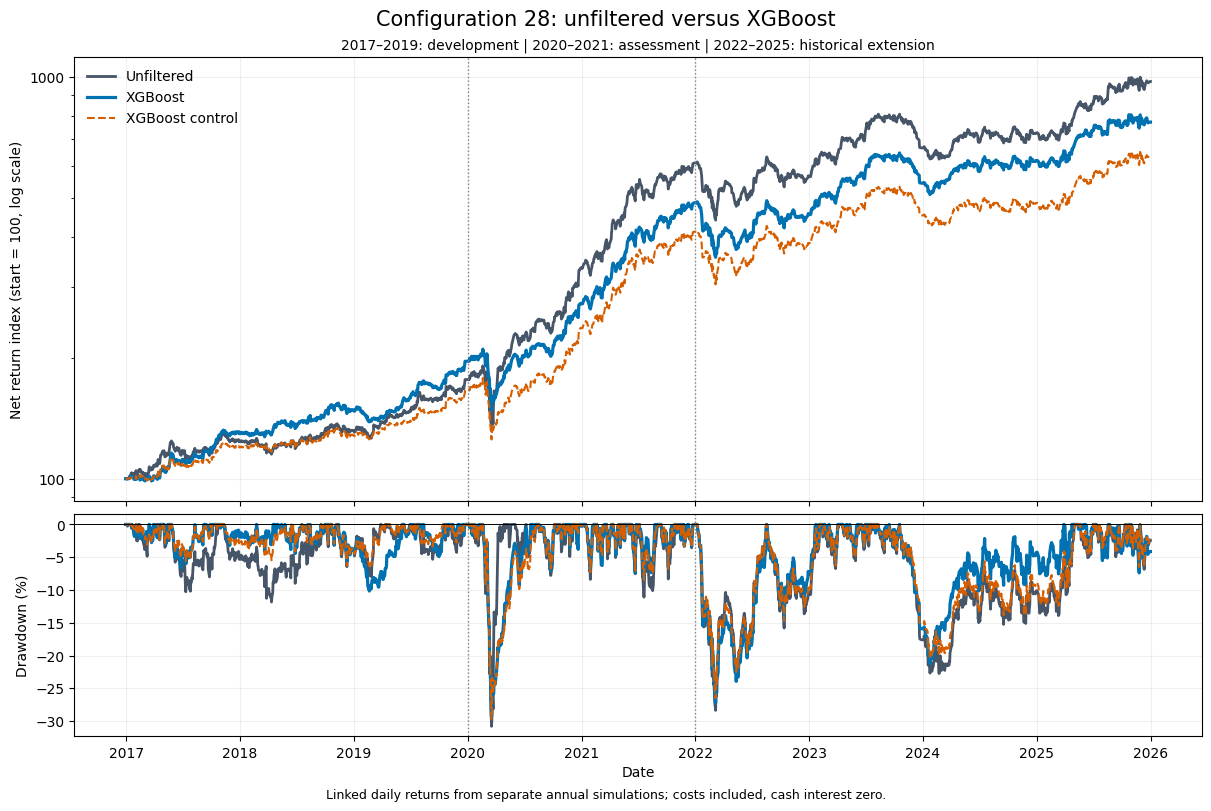

In [70]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
    constrained_layout=True,
)

styles = {
    "Unfiltered": {"color": "#475569", "linewidth": 2.0},
    "XGBoost": {"color": "#0072B2", "linewidth": 2.3},
    "XGBoost control": {
        "color": "#D55E00",
        "linewidth": 1.5,
        "linestyle": "--",
    },
}

for variant in COMPARISON_VARIANTS:
    axes[0].plot(
        comparison_equity.index,
        comparison_equity[variant],
        label=variant,
        **styles[variant],
    )
    axes[1].plot(
        comparison_drawdown.index,
        comparison_drawdown[variant],
        **styles[variant],
    )

axes[0].set_yscale("log")
axes[0].yaxis.set_major_formatter(ScalarFormatter())
axes[0].set_ylabel("Net return index (start = 100, log scale)")
axes[0].legend(loc="upper left", frameon=False)
axes[0].set_title(
    "2017–2019: development | 2020–2021: assessment | "
    "2022–2025: historical extension",
    fontsize=10,
)

axes[1].set_ylabel("Drawdown (%)")
axes[1].set_xlabel("Date")
axes[1].axhline(0, color="black", linewidth=0.7)

for ax in axes:
    ax.grid(alpha=0.2)
    for boundary in ("2020-01-01", "2022-01-01"):
        ax.axvline(
            pd.Timestamp(boundary),
            color="grey",
            linestyle=":",
            linewidth=1,
        )

fig.suptitle("Configuration 28: unfiltered versus XGBoost", fontsize=15)
fig.supxlabel(
    "Linked daily returns from separate annual simulations; "
    "costs included, cash interest zero.",
    fontsize=9,
)

plt.show()

In [71]:
import reversal_walk_forward

ML_WF_RULES = spec["walk_forward"].copy()
ML_WF_CONFIGS = tuple(grid.index)

# Reproduce the original 63-session selection calendar.
ml_wf_dates = continuation_schedule.loc[
    pd.Timestamp(spec["rebalance_anchor"]):
].index[1:]

ml_wf_refit_folds = reversal_walk_forward.build_walk_forward_folds(
    pd.DataFrame({"calendar_marker": 0.0}, index=ml_wf_dates),
    continuation_schedule,
    initial_train_sessions=ML_WF_RULES["initial_train_sessions"],
    test_sessions=ML_WF_RULES["test_sessions"],
)

# Both selectors will rank performance starting with the first
# period for which genuinely forward predictions can be generated.
ml_wf_scoring_start = ml_wf_refit_folds.iloc[0]["test_start"]

ml_wf_choice_folds = ml_wf_refit_folds.copy()
ml_wf_choice_folds["train_start"] = ml_wf_scoring_start
ml_wf_choice_folds["train_sessions"] -= (
    ML_WF_RULES["initial_train_sessions"]
)

ml_wf_choice_folds = ml_wf_choice_folds.loc[
    ml_wf_choice_folds["train_sessions"]
    >= ML_WF_RULES["initial_train_sessions"]
].copy()

print("Configurations:", len(ML_WF_CONFIGS))
print("Forward prediction history begins:", ml_wf_scoring_start.date())
print(
    "Adaptive trading begins:",
    ml_wf_choice_folds.iloc[0]["test_start"].date(),
)

display(
    ml_wf_choice_folds[
        ["train_start", "selection_date",
         "test_start", "test_end", "train_sessions"]
    ].head()
)

Configurations: 36
Forward prediction history begins: 2017-03-27
Adaptive trading begins: 2019-03-25


,train_start,selection_date,test_start,test_end,train_sessions
fold,,,,,
8,2017-03-27,2019-03-22,2019-03-25,2019-06-25,504
9,2017-03-27,2019-06-25,2019-06-26,2019-09-23,567
10,2017-03-27,2019-09-23,2019-09-24,2019-12-19,630
11,2017-03-27,2019-12-19,2019-12-20,2020-03-20,693
12,2017-03-27,2020-03-20,2020-03-23,2020-06-23,756


In [73]:
ml_wf_grid = grid.loc[list(ML_WF_CONFIGS)].copy()

# Reuse the existing outcomes, adding the five-session horizon.
ml_wf_outcome_panels = dict(continuation_outcome_panels)

for holding in sorted(ml_wf_grid["holding_sessions"].unique()):
    holding = int(holding)

    if holding not in ml_wf_outcome_panels:
        ml_wf_outcome_panels[holding] = (
            reversal_features.build_forward_outcomes(
                continuation_prices,
                continuation_schedule,
                horizon=holding,
            )
            .set_index("ticker", append=True)
            .sort_index()
        )

ml_wf_positions = np.arange(len(continuation_schedule))
ml_wf_decision_dates = {}
ml_wf_candidate_parts = {}

for config in ml_wf_grid.itertuples():
    config_id = int(config.Index)
    holding = int(config.holding_sessions)
    formation = int(config.formation_sessions)

    calendar = reversal_validation.build_rebalance_calendar(
        continuation_schedule,
        anchor=pd.Timestamp(spec["rebalance_anchor"]),
        rebalance_sessions=int(config.rebalance_sessions),
    )

    complete_horizon = (
        ml_wf_positions + 1 + holding < len(continuation_schedule)
    )
    dates = continuation_schedule.index[
        calendar["is_rebalance"].to_numpy() & complete_horizon
    ]

    # Keep every decision date, including dates with no selected stocks.
    ml_wf_decision_dates[config_id] = dates

    features = continuation_feature_panels[formation]
    ranked = reversal_validation.select_reversal_candidates(
        features.loc[
            features.index.get_level_values("Date").isin(dates)
        ],
        score_column="raw_reversal_score",
        top_frac=float(config.top_frac),
        min_eligible=int(spec["minimum_eligible"]),
    )

    selected = ranked.loc[ranked["selected"]].copy()

    selected["uncapped_target_weight"] = (
        1.0 / selected["target_slots"]
    )
    selected["base_target_weight"] = (
        selected["uncapped_target_weight"]
        .clip(upper=MAX_TARGET_WEIGHT)
    )

    selected["top_frac"] = float(config.top_frac)
    selected["holding_sessions"] = holding
    selected["rebalance_sessions"] = int(config.rebalance_sessions)

    # Select trades first, then attach their eventual outcomes.
    # Missing outcomes must not remove potential trades.
    ml_wf_candidate_parts[config_id] = selected.join(
        ml_wf_outcome_panels[holding][outcome_columns],
        how="left",
        validate="one_to_one",
    )

ml_wf_candidates = pd.concat(
    ml_wf_candidate_parts,
    names=["configuration_id"],
).sort_index()

assert ml_wf_candidates.index.is_unique

ml_wf_candidate_summary = (
    ml_wf_candidates.groupby(level="configuration_id")
    .agg(
        candidate_trades=("outcome_observed", "size"),
        known_outcomes=("outcome_observed", "sum"),
    )
)
ml_wf_candidate_summary["missing_outcomes"] = (
    ml_wf_candidate_summary["candidate_trades"]
    - ml_wf_candidate_summary["known_outcomes"]
)

display(
    ml_wf_grid[
        ["formation_sessions", "top_frac", "holding_sessions"]
    ].join(ml_wf_candidate_summary)
)

,formation_sessions,top_frac,holding_sessions,candidate_trades,known_outcomes,missing_outcomes
configuration_id,,,,,,
0,1,0.1,1,29950,29950,0
1,1,0.1,3,9976,9975,1
2,1,0.1,5,5977,5977,0
3,1,0.2,1,58379,58378,1
4,1,0.2,3,19438,19435,3
5,1,0.2,5,11650,11649,1
6,1,0.3,1,86369,86365,4
7,1,0.3,3,28704,28700,4
8,1,0.3,5,17293,17292,1


In [74]:
ml_wf_model_data = ml_wf_candidates.join(
    continuation_context_features,
    on=["Date", "ticker"],
    how="left",
    validate="many_to_one",
).sort_index()

ml_wf_model_data["features_ready"] = np.isfinite(
    ml_wf_model_data[FEATURE_COLUMNS]
).all(axis=1)

assert len(ml_wf_model_data) == len(ml_wf_candidates)
assert ml_wf_model_data.index.is_unique

# All 36 configurations must reproduce their earlier 2015–2021 data.
# Exclude trades whose planned exits fall outside that earlier history.
earlier_exit = ml_wf_model_data["exit_time"].lt(
    pd.Timestamp("2022-01-01", tz="UTC")
)

pd.testing.assert_frame_equal(
    ml_wf_model_data.loc[earlier_exit, model_data.columns],
    model_data,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

# Configurations 12 and 28 must also reproduce the full continuation data.
existing_configs = (
    ml_wf_model_data.index.get_level_values("configuration_id")
    .isin(CONTINUATION_CONFIGS)
)

pd.testing.assert_frame_equal(
    ml_wf_model_data.loc[
        existing_configs, continuation_model_data.columns
    ],
    continuation_model_data,
    check_exact=False,
    rtol=1e-12,
    atol=1e-12,
)

ml_wf_data_summary = (
    ml_wf_model_data.groupby(level="configuration_id")
    .agg(
        candidate_trades=("features_ready", "size"),
        complete_features=("features_ready", "sum"),
        observed_outcomes=("outcome_observed", "sum"),
    )
)

print("All 36 configurations match the earlier development data.")
print("Configurations 12 and 28 match the full continuation data.")
display(ml_wf_data_summary)

All 36 configurations match the earlier development data.
Configurations 12 and 28 match the full continuation data.


,candidate_trades,complete_features,observed_outcomes
configuration_id,,,
0,29950,29950,29950
1,9976,9976,9975
2,5977,5977,5977
3,58379,58379,58378
4,19438,19438,19435
5,11650,11650,11649
6,86369,86369,86365
7,28704,28704,28700
8,17293,17293,17292


In [75]:
ml_wf_signal_time = ml_wf_model_data["signal_time"]
ml_wf_exit_time = ml_wf_model_data["exit_time"]
ml_wf_usable_example = (
    ml_wf_model_data["features_ready"]
    & ml_wf_model_data["outcome_observed"]
)

ml_wf_splits = {}
ml_wf_split_rows = []
ml_wf_prediction_coverage = pd.Series(
    0, index=ml_wf_model_data.index, dtype="int16"
)

for fold in ml_wf_refit_folds.itertuples():
    cutoff = fold.selection_time
    block_end = continuation_schedule.at[
        fold.test_end, "market_close"
    ]

    # Only completed, observable outcomes can enter training.
    train_mask = (
        ml_wf_usable_example
        & ml_wf_signal_time.lt(cutoff)
        & ml_wf_exit_time.le(cutoff)
    )

    # Include signals at this selection close.
    # Signals at the next selection close belong to the next model.
    candidate_mask = (
        ml_wf_signal_time.ge(cutoff)
        & ml_wf_signal_time.lt(block_end)
    )

    # Candidates can exit after this block or have missing outcomes.
    training_counts = (
        train_mask.groupby(level="configuration_id").sum()
        .reindex(ml_wf_grid.index, fill_value=0)
    )

    if training_counts.eq(0).any():
        raise ValueError(
            f"A configuration has no training examples: fold {fold.Index}"
        )

    assert not (train_mask & candidate_mask).any()

    ml_wf_splits[fold.Index] = {
        "train_mask": train_mask,
        "candidate_mask": candidate_mask,
    }
    ml_wf_prediction_coverage += candidate_mask.astype("int16")

    ml_wf_split_rows.append({
        "fold": fold.Index,
        "selection_date": fold.selection_date,
        "last_training_exit": ml_wf_exit_time.loc[train_mask].max(),
        "training_rows": int(train_mask.sum()),
        "smallest_configuration_training_set": int(training_counts.min()),
        "candidate_rows": int(candidate_mask.sum()),
        "exits_after_block": int(
            (candidate_mask & ml_wf_exit_time.gt(block_end)).sum()
        ),
    })

# Every candidate in the forecasting period belongs to exactly one model.
ml_wf_expected_candidates = (
    ml_wf_signal_time.ge(
        ml_wf_refit_folds.iloc[0]["selection_time"]
    )
    & ml_wf_signal_time.lt(
        continuation_schedule.at[
            ml_wf_refit_folds.iloc[-1]["test_end"], "market_close"
        ]
    )
)

np.testing.assert_array_equal(
    ml_wf_prediction_coverage.to_numpy(),
    ml_wf_expected_candidates.to_numpy(dtype="int16"),
)

ml_wf_split_summary = (
    pd.DataFrame(ml_wf_split_rows).set_index("fold")
)

print(
    f"Prepared {len(ml_wf_splits)} refits "
    f"for each of {len(ml_wf_grid)} configurations."
)
print("Forecast coverage is complete and has no duplicated candidates.")
display(ml_wf_split_summary.iloc[[0, 7, 8, -1]])

Prepared 36 refits for each of 36 configurations.
Forecast coverage is complete and has no duplicated candidates.


,selection_date,last_training_exit,training_rows,smallest_configuration_training_set,candidate_rows,exits_after_block
fold,,,,,,
0,2017-03-24,2017-03-24 08:00:00+00:00,103650,590,20251,576
7,2018-12-20,2018-12-20 08:00:00+00:00,237881,1339,17897,576
8,2019-03-22,2019-03-22 08:00:00+00:00,255814,1445,21443,720
35,2025-12-16,2025-12-16 08:00:00+00:00,1064496,5939,4407,0


In [76]:
from sklearn.base import clone

ml_wf_models = {}
ml_wf_prediction_parts = {}
ml_wf_fit_rows = []

for completed, (fold_id, split) in enumerate(
    ml_wf_splits.items(), start=1
):
    training_for_fold = ml_wf_model_data.loc[
        split["train_mask"], FEATURE_COLUMNS + ["forward_return"]
    ]
    candidates_for_fold = ml_wf_model_data.loc[
        split["candidate_mask"], FEATURE_COLUMNS + ["features_ready"]
    ]
    candidate_config_ids = (
        candidates_for_fold.index.get_level_values("configuration_id")
    )

    predictions = pd.DataFrame(
        np.nan,
        index=candidates_for_fold.index,
        columns=["xgb_prediction"],
    )

    for config_id in ML_WF_CONFIGS:
        training = training_for_fold.xs(
            config_id, level="configuration_id"
        )
        predictable = candidates_for_fold.loc[
            (candidate_config_ids == config_id)
            & candidates_for_fold["features_ready"],
            FEATURE_COLUMNS,
        ]

        training_mean = float(training["forward_return"].mean())

        # Copy the fixed settings and fit from scratch.
        # The starting prediction uses this training period only.
        model = clone(xgb_models[config_id]).set_params(
            base_score=training_mean
        )
        model.fit(
            training[FEATURE_COLUMNS],
            training["forward_return"],
        )
        ml_wf_models[(fold_id, config_id)] = model

        if not predictable.empty:
            forecast = model.predict(predictable)

            if not np.isfinite(forecast).all():
                raise ValueError(
                    f"Invalid forecast: fold {fold_id}, "
                    f"configuration {config_id}"
                )

            predictions.loc[
                predictable.index, "xgb_prediction"
            ] = forecast

        ml_wf_fit_rows.append({
            "fold": fold_id,
            "configuration_id": config_id,
            "training_rows": len(training),
            "prediction_rows": len(predictable),
            "training_mean": training_mean,
        })

    ml_wf_prediction_parts[fold_id] = predictions

    print(
        f"Refit {completed}/{len(ml_wf_splits)} complete: "
        f"{len(ml_wf_models)} models fitted.",
        flush=True,
    )

ml_wf_predictions = pd.concat(
    ml_wf_prediction_parts, names=["fold"]
).sort_index()

ml_wf_fit_summary = (
    pd.DataFrame(ml_wf_fit_rows)
    .set_index(["fold", "configuration_id"])
    .sort_index()
)

# Confirm that every candidate was retained exactly once.
ml_wf_flat_predictions = (
    ml_wf_predictions.droplevel("fold").sort_index()
)
ml_wf_expected_rows = ml_wf_model_data.loc[
    ml_wf_expected_candidates
]

pd.testing.assert_index_equal(
    ml_wf_flat_predictions.index,
    ml_wf_expected_rows.index,
)
assert ml_wf_flat_predictions.index.is_unique

assert np.isfinite(
    ml_wf_flat_predictions.loc[
        ml_wf_expected_rows["features_ready"], "xgb_prediction"
    ]
).all()

assert len(ml_wf_models) == (
    len(ml_wf_splits) * len(ML_WF_CONFIGS)
)

print(
    f"Finished: {len(ml_wf_models):,} models and "
    f"{len(ml_wf_predictions):,} candidate rows."
)

display(
    ml_wf_fit_summary.groupby(level="fold")[
        ["training_rows", "prediction_rows"]
    ].sum()
)

Refit 1/36 complete: 36 models fitted.
Refit 2/36 complete: 72 models fitted.
Refit 3/36 complete: 108 models fitted.
Refit 4/36 complete: 144 models fitted.
Refit 5/36 complete: 180 models fitted.
Refit 6/36 complete: 216 models fitted.
Refit 7/36 complete: 252 models fitted.
Refit 8/36 complete: 288 models fitted.
Refit 9/36 complete: 324 models fitted.
Refit 10/36 complete: 360 models fitted.
Refit 11/36 complete: 396 models fitted.
Refit 12/36 complete: 432 models fitted.
Refit 13/36 complete: 468 models fitted.
Refit 14/36 complete: 504 models fitted.
Refit 15/36 complete: 540 models fitted.
Refit 16/36 complete: 576 models fitted.
Refit 17/36 complete: 612 models fitted.
Refit 18/36 complete: 648 models fitted.
Refit 19/36 complete: 684 models fitted.
Refit 20/36 complete: 720 models fitted.
Refit 21/36 complete: 756 models fitted.
Refit 22/36 complete: 792 models fitted.
Refit 23/36 complete: 828 models fitted.
Refit 24/36 complete: 864 models fitted.
Refit 25/36 complete: 900 m

,training_rows,prediction_rows
fold,,
0,103650,20251
1,123893,17367
2,141247,16455
3,157874,15819
4,173347,22684
5,196047,21149
6,217252,20609
7,237881,17897
8,255814,21443


In [77]:
ml_wf_allocations = ml_wf_model_data.loc[
    ml_wf_flat_predictions.index,
    [
        "signal_time",
        "uncapped_target_weight",
        "base_target_weight",
        "features_ready",
        "holding_sessions",
    ],
].join(ml_wf_flat_predictions, validate="one_to_one")

ml_wf_ready = ml_wf_allocations["features_ready"]
ml_wf_forecast = ml_wf_allocations["xgb_prediction"]

if not np.isfinite(ml_wf_forecast.loc[ml_wf_ready]).all():
    raise ValueError("A usable candidate is missing its forecast.")

# Preserve the existing fallback: retain trades with missing features.
ml_wf_keep = (
    ml_wf_forecast.gt(PREDICTION_THRESHOLD) | ~ml_wf_ready
)
ml_wf_allocations["xgb_keep"] = ml_wf_keep

# Uncapped weights reproduce the original configuration-ranking procedure.
ml_wf_allocations["xgb_uncapped_weight"] = (
    ml_wf_allocations["uncapped_target_weight"]
    .where(ml_wf_keep, 0.0)
)

# The final selected portfolio will use the 5%-capped weights.
ml_wf_allocations["xgb_target_weight"] = (
    ml_wf_allocations["base_target_weight"]
    .where(ml_wf_keep, 0.0)
)

ml_wf_weight_columns = [
    "uncapped_target_weight",
    "xgb_uncapped_weight",
    "base_target_weight",
    "xgb_target_weight",
]
ml_wf_weights = ml_wf_allocations[ml_wf_weight_columns]

assert np.isfinite(ml_wf_weights.to_numpy()).all()
assert ml_wf_weights.ge(0).all().all()
assert ml_wf_allocations["xgb_target_weight"].le(
    ml_wf_allocations["base_target_weight"]
).all()

np.testing.assert_allclose(
    ml_wf_allocations["xgb_uncapped_weight"].clip(
        upper=MAX_TARGET_WEIGHT
    ),
    ml_wf_allocations["xgb_target_weight"],
    rtol=1e-12,
    atol=1e-12,
)

ml_wf_target_exposure = ml_wf_weights.groupby(
    level=["configuration_id", "Date"]
).sum()

assert ml_wf_target_exposure.le(1 + 1e-12).all().all()

ml_wf_filter_summary = (
    ml_wf_allocations.groupby(level="configuration_id")
    .agg(
        candidate_trades=("xgb_keep", "size"),
        retained_trades=("xgb_keep", "sum"),
    )
)
ml_wf_filter_summary["retained_pct"] = (
    100 * ml_wf_filter_summary["retained_trades"]
    / ml_wf_filter_summary["candidate_trades"]
)

print("Raw and XGBoost allocations prepared.")
print("Rejected allocations remain in cash.")
display(ml_wf_filter_summary.round(2))

Raw and XGBoost allocations prepared.
Rejected allocations remain in cash.


,candidate_trades,retained_trades,retained_pct
configuration_id,,,
0,26957,9791,36.32
1,8978,4811,53.59
2,5378,2898,53.89
3,52699,12638,23.98
4,17546,7587,43.24
5,10513,5763,54.82
6,78046,15966,20.46
7,25952,10571,40.73
8,15622,8694,55.65


In [78]:
ml_wf_cash_date = ml_wf_refit_folds.iloc[0]["selection_date"]
ml_wf_score_schedule = continuation_schedule.loc[ml_wf_cash_date:]
ml_wf_score_market = continuation_market.loc[ml_wf_cash_date:]
ml_wf_score_tickers = (
    ml_wf_score_market.index.get_level_values("ticker")
    .unique().sort_values()
)

ml_wf_score_columns = {
    "Unfiltered": "uncapped_target_weight",
    "XGBoost": "xgb_uncapped_weight",
}


def run_ml_wf_scoring_case(config_id, variant):
    holding = int(ml_wf_grid.loc[config_id, "holding_sessions"])

    dates = ml_wf_decision_dates[config_id]
    dates = dates[dates >= ml_wf_cash_date]
    dates = dates.union(pd.DatetimeIndex([ml_wf_cash_date]))

    index = pd.MultiIndex.from_product(
        [dates, ml_wf_score_tickers],
        names=["Date", "ticker"],
    )

    allocations = ml_wf_allocations.xs(
        config_id, level="configuration_id"
    )
    assert allocations.index.isin(index).all()

    weight_column = ml_wf_score_columns[variant]
    decisions = (
        allocations[[weight_column]]
        .rename(columns={weight_column: "target_weight"})
        .reindex(index, fill_value=0.0)
    )
    decisions["signal_time"] = (
        decisions.index.get_level_values("Date")
        .map(ml_wf_score_schedule["market_close"])
    )

    # Benchmark: all eligible stocks at matching planned exposure.
    eligible = continuation_eligible.reindex(index)
    if eligible.isna().any():
        raise ValueError("Missing benchmark eligibility.")

    counts = eligible.groupby(level="Date").transform("sum")
    exposure = (
        decisions["target_weight"]
        .groupby(level="Date").transform("sum")
    )

    benchmark = decisions[["signal_time"]].copy()
    benchmark["target_weight"] = (
        eligible.astype(float).mul(exposure)
        .div(counts.where(counts.gt(0)))
        .fillna(0.0)
    )

    np.testing.assert_allclose(
        benchmark["target_weight"].groupby(level="Date").sum(),
        decisions["target_weight"].groupby(level="Date").sum(),
        rtol=1e-12,
        atol=1e-12,
    )

    daily_results = {}

    for role, targets in {
        "Strategy": decisions,
        "Benchmark": benchmark,
    }.items():
        result = reversal_backtest.run_execution_backtest(
            decisions=targets,
            market=ml_wf_score_market,
            schedule=ml_wf_score_schedule,
            initial_capital_gbp=INITIAL_CAPITAL,
            holding_sessions=holding,
            cost_per_side_bps=ML_WF_RULES["cost_per_side_bps"],
            net_orders=spec["net_orders"],
        )

        daily = result["daily"]
        pd.testing.assert_index_equal(
            daily.index, ml_wf_score_schedule.index
        )
        assert np.isclose(
            daily["equity_gbp"].iloc[0], INITIAL_CAPITAL
        )
        assert np.isfinite(daily["equity_gbp"]).all()
        assert np.isfinite(daily["equity_return"].iloc[1:]).all()

        if result["final_positions"]:
            raise ValueError(
                f"Unresolved final positions: "
                f"{config_id}, {variant}, {role}"
            )

        daily_results[role] = daily.copy()

    return daily_results


# Keep these results so the full sweep can reuse them.
ml_wf_scoring_daily = {}

for variant in ml_wf_score_columns:
    pilot = run_ml_wf_scoring_case(28, variant)

    for role, daily in pilot.items():
        ml_wf_scoring_daily[(28, variant, role)] = daily

    print(
        f"Configuration 28, {variant}: "
        "strategy and benchmark complete.",
        flush=True,
    )

print(
    f"Scoring return dates: "
    f"{ml_wf_score_schedule.index[1].date()} to "
    f"{ml_wf_score_schedule.index[-1].date()} "
    f"({len(ml_wf_score_schedule) - 1} sessions)."
)

Configuration 28, Unfiltered: strategy and benchmark complete.
Configuration 28, XGBoost: strategy and benchmark complete.
Scoring return dates: 2017-03-27 to 2025-12-31 (2214 sessions).


In [79]:
ml_wf_scoring_cases = [
    (int(config_id), variant)
    for config_id in ML_WF_CONFIGS
    for variant in ml_wf_score_columns
]
ml_wf_scoring_roles = ("Strategy", "Benchmark")

# Preserve completed results, including the configuration-28 pilot.
for number, (config_id, variant) in enumerate(
    ml_wf_scoring_cases, start=1
):
    already_complete = all(
        (config_id, variant, role) in ml_wf_scoring_daily
        for role in ml_wf_scoring_roles
    )

    if already_complete:
        status = "reused"
    else:
        case_results = run_ml_wf_scoring_case(config_id, variant)

        for role, daily in case_results.items():
            ml_wf_scoring_daily[(config_id, variant, role)] = daily

        status = "completed"

    print(
        f"Case {number}/{len(ml_wf_scoring_cases)}: "
        f"configuration {config_id}, {variant} — {status}.",
        flush=True,
    )

# Assemble aligned daily returns for every configuration.
ml_wf_scoring_returns = {}
ml_wf_expected_return_dates = ml_wf_score_schedule.index[1:]

for variant in ml_wf_score_columns:
    for role in ml_wf_scoring_roles:
        returns = pd.DataFrame({
            int(config_id): (
                ml_wf_scoring_daily[
                    (int(config_id), variant, role)
                ]["equity_return"].iloc[1:]
            )
            for config_id in ML_WF_CONFIGS
        }).rename_axis(columns="configuration_id")

        pd.testing.assert_index_equal(
            returns.index,
            ml_wf_expected_return_dates,
        )
        pd.testing.assert_index_equal(
            returns.columns,
            ml_wf_grid.index,
        )

        if not np.isfinite(returns.to_numpy()).all():
            raise ValueError(
                f"Missing or invalid scoring returns: {variant}, {role}"
            )

        ml_wf_scoring_returns[(variant, role)] = returns

# Original selection metric: daily strategy return minus
# its exposure-matched benchmark return, both after trading costs.
ml_wf_net_excess = {
    variant: (
        ml_wf_scoring_returns[(variant, "Strategy")]
        - ml_wf_scoring_returns[(variant, "Benchmark")]
    )
    for variant in ml_wf_score_columns
}

for variant, excess in ml_wf_net_excess.items():
    print(
        f"{variant}: {len(excess):,} sessions × "
        f"{excess.shape[1]} configurations."
    )

Case 1/72: configuration 0, Unfiltered — completed.
Case 2/72: configuration 0, XGBoost — completed.
Case 3/72: configuration 1, Unfiltered — completed.
Case 4/72: configuration 1, XGBoost — completed.
Case 5/72: configuration 2, Unfiltered — completed.
Case 6/72: configuration 2, XGBoost — completed.
Case 7/72: configuration 3, Unfiltered — completed.
Case 8/72: configuration 3, XGBoost — completed.
Case 9/72: configuration 4, Unfiltered — completed.
Case 10/72: configuration 4, XGBoost — completed.
Case 11/72: configuration 5, Unfiltered — completed.
Case 12/72: configuration 5, XGBoost — completed.
Case 13/72: configuration 6, Unfiltered — completed.
Case 14/72: configuration 6, XGBoost — completed.
Case 15/72: configuration 7, Unfiltered — completed.
Case 16/72: configuration 7, XGBoost — completed.
Case 17/72: configuration 8, Unfiltered — completed.
Case 18/72: configuration 8, XGBoost — completed.
Case 19/72: configuration 9, Unfiltered — completed.
Case 20/72: configuration 9, 

In [80]:
ml_wf_choices = {}

for variant, excess_returns in ml_wf_net_excess.items():
    ml_wf_choices[variant] = (
        reversal_walk_forward.select_walk_forward_configurations(
            net_returns=excess_returns,
            folds=ml_wf_choice_folds,
            grid=ml_wf_grid,
            rules=ML_WF_RULES,
        )
    )

# Compare the configurations chosen at each historical selection date.
ml_wf_choice_comparison = ml_wf_choice_folds[
    ["selection_date", "test_start", "test_end"]
].copy()

for variant, choices in ml_wf_choices.items():
    pd.testing.assert_index_equal(
        choices.index, ml_wf_choice_folds.index
    )

    ml_wf_choice_comparison[
        f"{variant}_configuration"
    ] = choices["configuration_id"]

print(f"Selection blocks: {len(ml_wf_choice_comparison)}")
print("A missing configuration means no new entries for that block.")
display(ml_wf_choice_comparison)

# Save the completed scoring and selection checkpoint.
ml_wf_checkpoint_dir = PROJECT / "data/ml_walk_forward_v1"
ml_wf_checkpoint_dir.mkdir(parents=True, exist_ok=True)

ml_wf_checkpoint_path = (
    ml_wf_checkpoint_dir / "selection_checkpoint.pkl"
)

pd.to_pickle(
    {
        "grid": ml_wf_grid,
        "rules": ML_WF_RULES,
        "folds": ml_wf_choice_folds,
        "scoring_daily": ml_wf_scoring_daily,
        "scoring_returns": ml_wf_scoring_returns,
        "net_excess": ml_wf_net_excess,
        "choices": ml_wf_choices,
    },
    ml_wf_checkpoint_path,
)

print("Saved:", ml_wf_checkpoint_path)

Selection blocks: 28
A missing configuration means no new entries for that block.


,selection_date,test_start,test_end,Unfiltered_configuration,XGBoost_configuration
fold,,,,,
8,2019-03-22,2019-03-25,2019-06-25,9,9
9,2019-06-25,2019-06-26,2019-09-23,9,9
10,2019-09-23,2019-09-24,2019-12-19,9,9
11,2019-12-19,2019-12-20,2020-03-20,9,9
12,2020-03-20,2020-03-23,2020-06-23,27,9
13,2020-06-23,2020-06-24,2020-09-21,27,9
14,2020-09-21,2020-09-22,2020-12-17,27,9
15,2020-12-17,2020-12-18,2021-03-19,27,9
16,2021-03-19,2021-03-22,2021-06-22,27,9


Saved: /Users/oscarlewis/Desktop/python/trading_portfolio/uk_portfolio/reversal_signals/data/ml_walk_forward_v1/selection_checkpoint.pkl


In [81]:
# The original builder expects one calendar per holding period.
ml_wf_calendars_by_holding = {}

for holding in sorted(ml_wf_grid["holding_sessions"].unique()):
    config_id = int(ml_wf_grid.index[
        ml_wf_grid["holding_sessions"].eq(holding)
    ][0])

    ml_wf_calendars_by_holding[int(holding)] = (
        ml_wf_decision_dates[config_id]
    )

ml_wf_selected_decisions = {}
ml_wf_selected_holding_lengths = {}
ml_wf_selected_rows = []

for variant, choices in ml_wf_choices.items():
    decisions = reversal_walk_forward.build_walk_forward_decisions(
        choices=choices,
        feature_panels=continuation_feature_panels,
        decision_dates_by_holding=ml_wf_calendars_by_holding,
        min_eligible=int(spec["minimum_eligible"]),
    )

    decisions = decisions[[
        "signal_time", "eligible", "target_weight",
        "holding_sessions", "configuration_id", "wf_fold",
    ]].copy()

    decisions["target_weight"] = decisions["target_weight"].clip(
        upper=MAX_TARGET_WEIGHT
    )

    candidates = decisions["target_weight"].gt(0)
    selected = decisions.loc[candidates]

    # Match each proposed trade to its configuration, date and stock.
    lookup_index = pd.MultiIndex.from_arrays(
        [
            selected["configuration_id"].to_numpy(dtype="int64"),
            selected.index.get_level_values("Date"),
            selected.index.get_level_values("ticker"),
        ],
        names=ml_wf_allocations.index.names,
    )
    allocation = ml_wf_allocations.reindex(lookup_index)

    if allocation[
        ["base_target_weight", "xgb_target_weight"]
    ].isna().any().any():
        raise ValueError(
            f"Missing selected-trade allocations: {variant}"
        )

    # Check that the builder reproduces our saved base allocations.
    np.testing.assert_allclose(
        decisions.loc[candidates, "target_weight"].to_numpy(),
        allocation["base_target_weight"].to_numpy(),
        rtol=1e-12,
        atol=1e-12,
    )

    if variant == "XGBoost":
        decisions.loc[candidates, "target_weight"] = (
            allocation["xgb_target_weight"].to_numpy()
        )

    assert decisions.index.is_unique
    assert np.isfinite(decisions["target_weight"]).all()
    assert decisions["target_weight"].between(
        0, MAX_TARGET_WEIGHT
    ).all()
    assert (
        decisions["target_weight"].groupby(level="Date")
        .sum().le(1 + 1e-12).all()
    )
    assert (
        decisions["holding_sessions"].groupby(level="Date")
        .nunique().eq(1).all()
    )

    ml_wf_selected_decisions[variant] = decisions
    ml_wf_selected_holding_lengths[variant] = (
        decisions["holding_sessions"]
        .groupby(level="Date").first().astype("int64")
    )

    ml_wf_selected_rows.append({
        "variant": variant,
        "decision_dates": len(
            ml_wf_selected_holding_lengths[variant]
        ),
        "candidate_trades": int(candidates.sum()),
        "positive_targets": int(
            decisions["target_weight"].gt(0).sum()
        ),
        "max_target_weight_pct": (
            100 * decisions["target_weight"].max()
        ),
    })

ml_wf_selected_summary = (
    pd.DataFrame(ml_wf_selected_rows).set_index("variant")
)
display(ml_wf_selected_summary)

,decision_dates,candidate_trades,positive_targets,max_target_weight_pct
variant,,,,
Unfiltered,1709,22675,22675,5.0
XGBoost,1157,15350,13042,5.0


In [82]:
from reversal_risk.execution import run_cash_interest_backtest

ML_WF_CASH_AER = 0.038

ml_wf_portfolio_cash_date = (
    ml_wf_choice_folds.iloc[0]["selection_date"]
)
ml_wf_portfolio_schedule = continuation_schedule.loc[
    ml_wf_portfolio_cash_date:
]
ml_wf_portfolio_market = continuation_market.loc[
    ml_wf_portfolio_cash_date:
]

ml_wf_portfolio_runs = {}
ml_wf_portfolio_rows = []

for variant, decisions in ml_wf_selected_decisions.items():
    # Match the strategy's planned exposure on each decision date.
    exposure = decisions["target_weight"].groupby(
        level="Date"
    ).transform("sum")
    eligible_count = decisions["eligible"].groupby(
        level="Date"
    ).transform("sum")

    benchmark = decisions[["signal_time"]].copy()
    benchmark["target_weight"] = (
        decisions["eligible"].astype(float)
        * exposure / eligible_count.clip(lower=1)
    )

    np.testing.assert_allclose(
        benchmark["target_weight"].groupby(level="Date").sum(),
        decisions["target_weight"].groupby(level="Date").sum(),
        atol=1e-12,
    )

    for portfolio, targets in {
        "Strategy": decisions,
        "Benchmark": benchmark,
    }.items():
        result = run_cash_interest_backtest(
            decisions=targets,
            market=ml_wf_portfolio_market,
            schedule=ml_wf_portfolio_schedule,
            initial_capital_gbp=INITIAL_CAPITAL,
            holding_sessions_by_date=(
                ml_wf_selected_holding_lengths[variant]
            ),
            cost_per_side_bps=COST_PER_SIDE_BPS,
            net_orders=True,
            cash_aer=ML_WF_CASH_AER,
        )
        daily = result["daily"]

        pd.testing.assert_index_equal(
            daily.index, ml_wf_portfolio_schedule.index
        )
        assert np.isfinite(daily["equity_gbp"]).all()
        assert np.isfinite(daily["equity_return"].iloc[1:]).all()
        assert daily["equity_gbp"].iloc[0] == INITIAL_CAPITAL
        assert not result["final_positions"]

        ml_wf_portfolio_runs[(variant, portfolio)] = result

        ml_wf_portfolio_rows.append({
            "variant": variant,
            "portfolio": portfolio,
            "ending_equity_gbp": daily["equity_gbp"].iloc[-1],
            "net_total_return_pct": 100 * (
                daily["equity_gbp"].iloc[-1] / INITIAL_CAPITAL - 1
            ),
            "max_drawdown_pct": 100 * (
                daily["equity_gbp"]
                / daily["equity_gbp"].cummax() - 1
            ).min(),
            "total_cost_gbp": daily["cost_gbp"].sum(),
            "cash_interest_gbp": daily["cash_interest_gbp"].sum(),
        })
        print(f"Finished: {variant} / {portfolio}")

ml_wf_portfolio_summary = pd.DataFrame(
    ml_wf_portfolio_rows
).set_index(["variant", "portfolio"])

display(ml_wf_portfolio_summary.round(2))

Finished: Unfiltered / Strategy
Finished: Unfiltered / Benchmark
Finished: XGBoost / Strategy
Finished: XGBoost / Benchmark


ending_equity_gbp  net_total_return_pct  \
variant    portfolio                                            
Unfiltered Strategy            58403.75                484.04   
           Benchmark           13253.95                 32.54   
XGBoost    Strategy            43118.21                331.18   
           Benchmark           12251.60                 22.52   

                      max_drawdown_pct  total_cost_gbp  cash_interest_gbp  
variant    portfolio                                                       
Unfiltered Strategy             -32.02        26890.63            2752.82  
           Benchmark            -28.15          613.84             985.82  
XGBoost    Strategy             -29.31        16397.52            2505.45  
           Benchmark            -25.68         1508.21            1199.53